This appendix contains all Python code used for data processing, analysis, and visualization in support of the research article "Health Care Utilization and Immigration Enforcement."

# Environment Setup

Import required libraries.

In [30]:
# Import libraries
import os
import json
import time
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
from bs4 import BeautifulSoup
import zipcodes
from scipy import stats
import matplotlib.ticker as mtick
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import openpyxl
import janitor

warnings.filterwarnings('ignore')

# Data Loading

Load the datasets for analysis.

## CDC PLACES: Routine checkup within the past year among adults (outcome, 2018-2023)

This data is available from CDC's PLACES data and provides information on the percentage of adults who reported having a routine checkup within the past year, by Zip Code Tabulation Area (ZCTA) and year from 2020-2025 (data years from 2018-2023). This data will serve as our primary outcome variable, allowing us to assess health care utilization patterns in relation to local enforcement intensity.

Load PLACES: Local Data for Better Health:

- 2025 releases (2023 data): [ZCTA Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-ZCTA-Data-2025/qnzd-25i4/about_data)

- 2024 releases (2022 data): [ZCTA Data](https://catalog.data.gov/dataset/places-local-data-for-better-health-zcta-data-2024-release)

- 2023 releases (2021 data): [ZCTA Data](https://data.cdc.gov/d/9umn-c3jf)

- 2022 releases (2020 data): [ZCTA Data](https://data.cdc.gov/d/gd4x-jyhw)

- 2021 releases (2019 data): [ZCTA Data](https://data.cdc.gov/d/s85h-9xpy)

- 2020 releases (2018 data): [ZCTA Data](https://data.cdc.gov/d/fbbf-hgkc)

> Note: Data released each year reflects BRFSS data from 2 years prior. For e.g., 2025 release reflects 2023 BRFSS data. 2016-2019 release data is also available, but data format is not consistent.

In [31]:
# Load CDC PLACES data
# Data source: CDC PLACES
# Time period: 2018-2023

file_templates = {
    "zip"   :   "./Data/places-local-data/PLACES__Local_Data_for_Better_Health,_ZCTA_Data_{release}_release.csv"
}

for release_year in range(2025, 2019, -1):  # 2025, 2024, ..., 2020
    data_year = release_year - 2
    globals()[f"places_zip_{data_year}"] = pd.read_csv(
        file_templates["zip"].format(release=release_year)
    )

## Census API: Demographic data (covariates, 2018-2023)

Merge on demographics from Census data to zip code level PLACES data.

In [32]:
# Census API: Demographic data (predictors)
CENSUS_KEY = os.getenv("CENSUS_API_KEY")  # set in your environment
ACS_VARS = [
    "NAME",
    # Race / ethnicity / citizenship
    "B02001_001E","B02001_002E","B02001_003E","B02001_004E","B02001_005E","B02001_006E","B02001_007E","B02001_008E",
    "B03003_001E","B03003_003E",
    "B05001_001E","B05001_005E","B05001_006E",
    # Additional SDOH controls
    "B19013_001E",
    "B17001_001E","B17001_002E",
    "B15003_001E","B15003_017E","B15003_018E","B15003_019E","B15003_020E","B15003_021E","B15003_022E","B15003_023E","B15003_024E","B15003_025E",
    "B23025_003E","B23025_005E",
    "B25070_001E","B25070_007E","B25070_008E","B25070_009E","B25070_010E",
    "B28002_001E","B28002_013E",
    "B08201_001E","B08201_002E"
]

# Define function to fetch ACS data for all ZCTAs for a given year
def fetch_acs_zcta(year: int, census_key: str | None = None) -> pd.DataFrame:
    base = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": ",".join(ACS_VARS),
        "for": "zip code tabulation area:*"
    }
    if census_key:
        params["key"] = census_key

    r = requests.get(base, params=params, timeout=120)
    r.raise_for_status()
    rows = r.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])

    # Standardized merge key
    df["zcta5"] = df["zip code tabulation area"].astype(str).str.zfill(5)
    df["acs_year"] = year

    numeric_cols = [c for c in df.columns if c.endswith("E")]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Friendly names
    df = df.rename(columns={
        "B02001_001E": "race_total",
        "B02001_002E": "white_alone",
        "B02001_003E": "black_alone",
        "B02001_004E": "aian_alone",
        "B02001_005E": "asian_alone",
        "B02001_006E": "nhpi_alone",
        "B02001_007E": "other_race_alone",
        "B02001_008E": "two_plus_races",

        "B03003_001E": "ethnicity_total",
        "B03003_003E": "hispanic_latino",

        "B05001_001E": "citizenship_total",
        "B05001_005E": "naturalized_citizen",
        "B05001_006E": "non_citizen",

        "B19013_001E": "median_household_income",
        "B17001_001E": "poverty_universe",
        "B17001_002E": "below_poverty",

        "B15003_001E": "education_25plus",
        "B15003_017E": "hs_grad",
        "B15003_018E": "ged",
        "B15003_019E": "some_college_lt1yr",
        "B15003_020E": "some_college_no_degree",
        "B15003_021E": "associate_degree",
        "B15003_022E": "bachelors",
        "B15003_023E": "masters",
        "B15003_024E": "professional_school",
        "B15003_025E": "doctorate",

        "B23025_003E": "labor_force",
        "B23025_005E": "unemployed",

        "B25070_001E": "renter_occupied",
        "B25070_007E": "rent_30_34pct",
        "B25070_008E": "rent_35_39pct",
        "B25070_009E": "rent_40_49pct",
        "B25070_010E": "rent_50plus_pct",

        "B28002_001E": "households_total",
        "B28002_013E": "no_internet_households",

        "B08201_001E": "households_vehicle",
        "B08201_002E": "no_vehicle_households"
    })

    # Shares (0-1)
    race_den = df["race_total"].replace(0, pd.NA)
    eth_den = df["ethnicity_total"].replace(0, pd.NA)
    cit_den = df["citizenship_total"].replace(0, pd.NA)
    pov_den = df["poverty_universe"].replace(0, pd.NA)
    edu_den = df["education_25plus"].replace(0, pd.NA)
    labor_den = df["labor_force"].replace(0, pd.NA)
    rent_den = df["renter_occupied"].replace(0, pd.NA)
    internet_den = df["households_total"].replace(0, pd.NA)
    vehicle_den = df["households_vehicle"].replace(0, pd.NA)

    df["pct_white"] = df["white_alone"] / race_den
    df["pct_black"] = df["black_alone"] / race_den
    df["pct_asian"] = df["asian_alone"] / race_den
    df["pct_two_plus"] = df["two_plus_races"] / race_den
    df["pct_other_race"] = (df["other_race_alone"] + df["aian_alone"] + df["nhpi_alone"]) / race_den

    df["pct_hispanic_latino"] = df["hispanic_latino"] / eth_den
    df["pct_non_hispanic_latino"] = 1 - df["pct_hispanic_latino"]

    df["pct_naturalized"] = df["naturalized_citizen"] / cit_den
    df["pct_non_citizen"] = df["non_citizen"] / cit_den
    df["pct_citizen"] = 1 - df["pct_non_citizen"]

    df["pct_below_poverty"] = df["below_poverty"] / pov_den
    df["pct_bachelors_plus"] = (
        df["bachelors"] + df["masters"] + df["professional_school"] + df["doctorate"]
    ) / edu_den
    df["pct_high_school_or_higher"] = (
        df["hs_grad"] + df["ged"] + df["some_college_lt1yr"] + df["some_college_no_degree"]
        + df["associate_degree"] + df["bachelors"] + df["masters"] + df["professional_school"] + df["doctorate"]
    ) / edu_den
    df["pct_unemployed"] = df["unemployed"] / labor_den
    df["pct_rent_burdened_30_plus"] = (
        df["rent_30_34pct"] + df["rent_35_39pct"] + df["rent_40_49pct"] + df["rent_50plus_pct"]
    ) / rent_den
    df["pct_no_internet"] = df["no_internet_households"] / internet_den
    df["pct_no_vehicle"] = df["no_vehicle_households"] / vehicle_den

    keep = [
        "zcta5",
        "acs_year",
        "pct_white",
        "pct_black",
        "pct_asian",
        "pct_two_plus",
        "pct_other_race",
        "pct_hispanic_latino",
        "pct_non_hispanic_latino",
        "pct_naturalized",
        "pct_non_citizen",
        "pct_citizen",
        "median_household_income",
        "pct_below_poverty",
        "pct_bachelors_plus",
        "pct_high_school_or_higher",
        "pct_unemployed",
        "pct_rent_burdened_30_plus",
        "pct_no_internet",
        "pct_no_vehicle"
    ]
    return df[keep]

# Setup Data Directory
DATA_DIR = "./Data/"
os.makedirs(DATA_DIR, exist_ok=True)

# Years to fetch ACS for (based on PLACES data)
places_data_years = set([2018, 2019, 2020, 2021, 2022, 2023])

# Fetch or load data for each year
acs_by_year = {}
for year in sorted(places_data_years):
    acs_save_dir = './Data/acs-zcta-data/'
    merged_save_dir = './Data/places-merged/'
    
    os.makedirs(acs_save_dir, exist_ok=True)
    os.makedirs(merged_save_dir, exist_ok=True)

    acs_save_location = f'./Data/acs-zcta-data/acs_zcta_{year}.csv'
    merged_save_location = f'./Data/places-merged/places_zip_{year}_demos.csv'

    try:
        # 1. Check & Load/Fetch ACS Data (Required for the dictionary to do cross-year merges)
        if os.path.exists(acs_save_location):
            print(f"Loading raw ACS data for {year} from disk...")
            # We explicitly define zcta5 as string so it doesn't drop leading zeros during import
            acs_by_year[year] = pd.read_csv(acs_save_location, dtype={"zcta5": str})
            # Ensure it stays exactly 5 digits just in case
            acs_by_year[year]["zcta5"] = acs_by_year[year]["zcta5"].astype(str).str.zfill(5)
        else:
            print(f"Fetching ACS data for {year} from API...")
            acs_by_year[year] = fetch_acs_zcta(year, CENSUS_KEY)
            acs_by_year[year].to_csv(acs_save_location, index=False)
            print(f"Saved ACS for {year}: {len(acs_by_year[year]):,} ZCTAs")

        # 2. Check & Load/Merge PLACES Data
        if os.path.exists(merged_save_location):
            print(f"Loading merged PLACES + ACS data for {year} from disk...")
            merged = pd.read_csv(merged_save_location, dtype={"zcta5": str})
            merged["zcta5"] = merged["zcta5"].astype(str).str.zfill(5)
            globals()[f"places_zip_{year}_demos"] = merged
        else:
            print(f"Merging PLACES data for {year}...")
            # Assuming globals()[f"places_zip_{year}"] is already defined earlier in your script
            places = globals()[f"places_zip_{year}"]
            
            # Standardized merge key
            places["zcta5"] = pd.to_numeric(places["LocationName"], errors="coerce").astype("Int64").astype(str).str.zfill(5)
            places["analysis_year"] = pd.to_numeric(places["Year"], errors="coerce").astype("Int64")

            merged_parts = []
            for y, sub in places.groupby("analysis_year", dropna=True):
                y = int(y)
                if y in acs_by_year:
                    merged_parts.append(sub.merge(acs_by_year[y], on="zcta5", how="left"))
                else:
                    merged_parts.append(sub)

            # Save as df
            merged = pd.concat(merged_parts, ignore_index=True)
            merged.to_csv(merged_save_location, index=False)
            globals()[f"places_zip_{year}_demos"] = merged
            print(f"Saved merged places_zip_{year}_demos: {len(merged):,} rows")
            
    except Exception as e:
        print(f"Skipping {year}: {e}") # Fixed the 'y' to 'year' here as well

Loading raw ACS data for 2018 from disk...
Loading merged PLACES + ACS data for 2018 from disk...
Loading raw ACS data for 2019 from disk...
Loading merged PLACES + ACS data for 2019 from disk...
Loading raw ACS data for 2020 from disk...
Loading merged PLACES + ACS data for 2020 from disk...
Loading raw ACS data for 2021 from disk...
Loading merged PLACES + ACS data for 2021 from disk...
Loading raw ACS data for 2022 from disk...
Loading merged PLACES + ACS data for 2022 from disk...
Loading raw ACS data for 2023 from disk...
Loading merged PLACES + ACS data for 2023 from disk...


In [33]:
# Among merged files, check if any have mismatched ACS and PLACES years which would indicate merge issues


## TRAC: Detention Facilities Average Daily Population (predictor, 2019-2026)

Load average daily population data from ICE detention facilities. This data is at the zip level.

In [34]:
# Load TRAC detention facilities data
# Data source: TRAC (Transactional Records Access Clearinghouse), retrieved 3/19/2026
# Time period: September 30, 2019 - February 5, 2026

detention_facilities = pd.read_excel('./Data/trac-detention-data/TRAC_DetentionFacilitiesAverageDailyPopulation.xlsx', skiprows=1)

detention_facilities.head()

,Name,City,State,Zip,Type Detailed*,Current Guaranteed Minimum,Average Daily Population,Current as of**
0,Total,NaN,NaN,NaN,NaN,44714,67141.0,2026-02-05
1,ADAMS COUNTY CORRECTIONAL CENTER,NATCHEZ,MS,39120.0,DIGSA,1436,2191.0,2026-02-05
2,ADELANTO ICE PROCESSING CENTER,ADELANTO,CA,92301.0,CDF,640,1802.0,2026-02-05
3,ALEXANDRIA STAGING FACILI,ALEXANDRIA,LA,71303.0,STAGING,NaN,410.0,2026-02-05
4,ALLEGANY COUNTY JAIL,BELMONT,NY,14813.0,USMS IGA,NaN,6.0,2026-02-05


In [35]:
# Define function to scrape data from TRAC website for all dropdown metrics (citizenship, gender, etc.) across all states and counties for a particular month and year.
def scrape_all_trac_metrics(period="1907"):
    print("Initializing API connection...")
    
    session = requests.Session()
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': 'text/html, */*; q=0.01',
        'X-Requested-With': 'XMLHttpRequest',
        'Referer': 'https://tracreports.org/phptools/immigration/detention/'
    }
    session.headers.update(headers)
    
    # Initial connection
    session.get('https://tracreports.org/phptools/immigration/detention/')
    api_base = "https://tracreports.org/phptools/immigration/detention/table.php"
    period = str(period)  # e.g., "1907" for July 2019
    print(f"Connected to TRAC API. Starting data extraction for period {period}...")
    
    # The list of all dropdown metrics from the TRAC website
    metrics_to_scrape = {
        "facility_type": "Facility Type",
        "type_detailed": "Facility Type (Detailed)",
        "facility_operator": "Facility Operator",
        "facility_owner": "Facility Owner",
        "fymon": "Entered ICE Custody by Month",
        "entry_grp_display": "Time in U.S.",
        "permanent_resident": "Legal Permanent Resident",
        "asylum_sought": "Asylum Seeker/Refugee",
        "most_ser_crim_conv": "Most Serious Criminal Conviction",
        "mscc_grp": "Seriousness Level of MSCC",
        "time_since_conv_disp": "Length of Time Since MSCC",
        "gender": "Gender",
        "citizenship": "Citizenship",
        "age_grp": "Age Group"
    }
    
    master_data = []

    # 1. Get ALL States
    print("Fetching State list...")
    state_url = f"{api_base}?stat=count&period={period}&dimension=state&sort=valdesc"
    state_resp = session.get(state_url)
    state_soup = BeautifulSoup(state_resp.text, 'html.parser')
    
    state_dict = {}
    for row in state_soup.select("tbody tr"):
        link = row.find('a')
        if link and "tableClick" in link.get('href', ''):
            state_name = link.text.strip()
            if state_name == "All":
                continue
            state_id = link['href'].split("'")[3]
            state_dict[state_name] = state_id

    print(f"Found {len(state_dict)} states. Beginning massive extraction...")

    # 2. Loop through ALL States
    for state_name, state_id in state_dict.items():
        print(f"\n--- Processing {state_name} ---")
        
        county_url = f"{api_base}?stat=count&period={period}&state={state_id}&dimension=county&sort=valdesc"
        county_resp = session.get(county_url)
        county_soup = BeautifulSoup(county_resp.text, 'html.parser')
        
        county_dict = {}
        for row in county_soup.select("tbody tr"):
            link = row.find('a')
            if link and "tableClick" in link.get('href', ''):
                county_name = link.text.strip()
                if county_name == "All":
                    continue
                county_id = link['href'].split("'")[3]
                county_dict[county_name] = county_id
                
        # 3. Loop through Counties
        for county_name, county_id in county_dict.items():
            
            # 4. Loop through every metric in our dictionary
            for metric_code, metric_name in metrics_to_scrape.items():
                
                metric_url = (
                    f"{api_base}?stat=count&period={period}&state={state_id}"
                    f"&county={county_id}&dimension={metric_code}&sort=valdesc"
                )
                
                try:
                    metric_resp = session.get(metric_url)
                    metric_soup = BeautifulSoup(metric_resp.text, 'html.parser')
                    
                    # Parse the resulting table
                    for row in metric_soup.select("tbody tr"):
                        cells = row.find_all('td')
                        
                        if len(cells) > 1:
                            category_name = cells[0].text.strip()
                            count_text = cells[1].text.replace(',', '').strip()
                            count = int(count_text) if count_text.isdigit() else 0
                            
                            master_data.append({
                                "State": state_name,
                                "County": county_name,
                                "Metric": metric_name,
                                "Category": category_name,
                                "Count": count
                            })
                            
                except Exception as e:
                    print(f"Error fetching {metric_name} for {county_name}: {e}")
                
                # Polite delay to prevent server overload
                time.sleep(0.1)

            print(f"Finished pulling all metrics for {county_name}")

    return pd.DataFrame(master_data)

In [36]:
# Call function to load data to df for multiple time snapshots.
# List periods
periods = ["1907", "1906", "1905", "1904", "1812", "1811", "1807", "1806", "1803", "1802"]

# Store each period's DataFrame in a dictionary
trac_county_metrics_by_period = {}

for period in periods:
    trac_file_path = Path(f"./Data/trac-detention-data/TRAC_ICE_detention_all_metrics_{period}.csv")

    if trac_file_path.exists():
        trac_df = pd.read_csv(trac_file_path)
    else:
        trac_df = scrape_all_trac_metrics(period=period)
        trac_df.to_csv(trac_file_path, index=False)

    trac_county_metrics_by_period[period] = trac_df
    globals()[f"trac_county_metrics_df_{period}"] = trac_df  # optional convenience

# Combined dataset across periods
trac_county_metrics_df = pd.concat(
    [df.assign(period=period) for period, df in trac_county_metrics_by_period.items()],
    ignore_index=True
)

# Preview
trac_county_metrics_df.head()

,State,County,Metric,Category,Count,period
0,Texas,"Frio County, TX",Facility Type,All,3037,1907
1,Texas,"Frio County, TX",Facility Type,Other Facility Type,3037,1907
2,Texas,"Frio County, TX",Facility Type (Detailed),All,3037,1907
3,Texas,"Frio County, TX",Facility Type (Detailed),Contract Detention Facility: owned by private ...,1996,1907
4,Texas,"Frio County, TX",Facility Type (Detailed),Family: a facility in which families are detai...,1041,1907


# Data Cleaning and Preprocessing

Clean, standardize, and prepare datasets for analysis.

## PLACES

We append data by ZCTA across years, handle missings, and fix data types. Only crude prevalence is available at the ZCTA level (not age-adjusted prevalence).

In [37]:
# Data cleaning steps:
# 1. Handle missing values
# 2. Standardize geographic identifiers (county FIPS codes, ZIP codes)
# 3. Convert date formats
# 4. Remove duplicates
# 5. Validate data quality

# Append places_zip_2018 - 2023
places_zip_all_years = pd.concat(
    [globals()[f"places_zip_{year}_demos"] for year in range(2018, 2024)],
    ignore_index=True
)

# Standardize column names and remove empty columns
places_zip_all_years = places_zip_all_years.clean_names().remove_empty()

# ZCTA5 codes should be zero-padded 5-digit strings
places_zip_all_years['zcta5'] = (
    places_zip_all_years['locationname']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Fix column data types
places_zip_all_years['totalpopulation'] = pd.to_numeric(
    places_zip_all_years['totalpopulation']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Drop the original locationname and locationid columns since we have the standardized zip code
places_zip_all_years = places_zip_all_years.drop(columns=['locationname'])
places_zip_all_years = places_zip_all_years.drop(columns=['locationid'])

# Rename data_value to more descriptive name
places_zip_all_years = places_zip_all_years.rename(columns={'data_value': 'doctor_visits_past_year'})

# Drop measure name
places_zip_all_years = places_zip_all_years.drop(columns=['measure'])

# Since totalpop18plus has significant missing values, we will drop it for now
places_zip_all_years = places_zip_all_years.drop(columns=['totalpop18plus'])

# Remove columns that have the same value for all rows--these are not useful for modeling
for col in places_zip_all_years.columns:
    if places_zip_all_years[col].nunique() == 1:
        places_zip_all_years = places_zip_all_years.drop(columns=[col]) 

# Drop duplicates, if any
places_zip_all_years = places_zip_all_years.drop_duplicates()

# Drop if doctor_visits_past_year is missing
places_zip_all_years = places_zip_all_years.dropna(subset=['doctor_visits_past_year'])
    
places_zip_all_years.info()

<class 'pandas.DataFrame'>
RangeIndex: 185504 entries, 0 to 185503
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   year                       185504 non-null  int64  
 1   doctor_visits_past_year    185504 non-null  float64
 2   low_confidence_limit       185504 non-null  float64
 3   high_confidence_limit      185504 non-null  float64
 4   totalpopulation            185504 non-null  int64  
 5   geolocation                185504 non-null  str    
 6   zcta5                      185504 non-null  str    
 7   analysis_year              185504 non-null  int64  
 8   acs_year                   185401 non-null  float64
 9   pct_white                  184805 non-null  float64
 10  pct_black                  184805 non-null  float64
 11  pct_asian                  184805 non-null  float64
 12  pct_two_plus               184805 non-null  float64
 13  pct_other_race             184805 non-nu

token: eyJhdWQiOiI2IiwianRpIjoiM2JiZGU4ZjNmYTRjNDI3NzY5M2IxY2Y3YmIxMTIzZjg5NTRkNTU2YzUwNjIzYjVkNzU1Y2ViMTRjZTJkYmQzOWExNjI3ZTFlY2IyZWRhNjYiLCJpYXQiOjE3NzUyNDU0NzkuMTY4NjM5LCJuYmYiOjE3NzUyNDU0NzkuMTY4NjQyLCJleHAiOjIwOTA4NjQ2NzkuMTY0NTUxLCJzdWIiOiIxMjQ1NjAiLCJzY29wZXMiOltdfQ

In [38]:
places_zip_all_years.head()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zcta5,analysis_year,acs_year,pct_white,...,pct_non_citizen,pct_citizen,median_household_income,pct_below_poverty,pct_bachelors_plus,pct_high_school_or_higher,pct_unemployed,pct_rent_burdened_30_plus,pct_no_internet,pct_no_vehicle
0,2018,80.5,80.2,80.9,16769,POINT (-72.62581515 42.06255509),01001,2018,2018.0,0.924806,...,0.020714,0.979286,62144.0,0.089569,0.324993,0.914791,0.034201,0.506760,0.162946,0.084748
1,2018,75.6,75.1,76.1,29049,POINT (-72.4509085 42.38758794),01002,2018,2018.0,0.757666,...,0.109060,0.890940,55858.0,0.286926,0.670131,0.951649,0.059449,0.579921,0.064291,0.116128
2,2018,70.5,68.3,72.5,10372,POINT (-72.52475918 42.39190728),01003,2018,2018.0,0.743104,...,0.081242,0.918758,2499.0,0.792683,0.152542,0.771186,0.184043,0.312500,0.000000,0.000000
3,2018,78.1,77.4,78.8,5079,POINT (-72.10611705 42.42009493),01005,2018,2018.0,0.951513,...,0.004208,0.995792,68278.0,0.068674,0.323620,0.961334,0.059283,0.414384,0.145717,0.045050
4,2018,77.5,76.9,78.0,14649,POINT (-72.40031647 42.27869142),01007,2018,2018.0,0.947284,...,0.017706,0.982294,93300.0,0.052780,0.478063,0.947332,0.039884,0.409736,0.075434,0.051142


## TRAC: Average Daily Population

We standardize columns names, correct data types, and handle missings.

In [39]:
detention_facilities_clean = detention_facilities.copy()

# Use janitor to clean column names
detention_facilities_clean = detention_facilities_clean.clean_names(remove_special=True)

# Drop if zip code is missing (not useful for analysis)
detention_facilities_clean = detention_facilities_clean.dropna(subset=['zip'])

# Update data types. ZIP codes should be zero-padded 5-digit strings
detention_facilities_clean['zip'] = (
    detention_facilities_clean['zip']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Current Guaranteed Minimum has too many missing values and we can use the total population column instead, so we will drop this column
detention_facilities_clean = detention_facilities_clean.drop(columns=['current_guaranteed_minimum'])

# State has 3 missing values, investigate:
print(detention_facilities_clean[detention_facilities_clean['state'].isna()])

# Impute state based on zip code for missing values
detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'state'] = detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'zip'].map({
    '92301': 'CA',
    '33073': 'FL',
    '71342': 'LA',
    '92301': 'CA'
})

# Map ZIP codes to ZCTAs using HHRSA ZIP-to-ZCTA crosswalk
# Load crosswalk
zip_to_zcta = pd.read_excel('Data/ZIP Code to ZCTA Crosswalk.xlsx').clean_names()
# Standardize ZIP code format in crosswalk
zip_to_zcta['zip_code'] = (zip_to_zcta['zip_code'].astype(int).astype(str).str.zfill(5))
# Merge onto detention facilities data
detention_facilities_clean = detention_facilities_clean.merge(zip_to_zcta[['zip_code', 'zcta']], left_on='zip', right_on='zip_code', how='left')
# Rename zcta to zcta5 for consistency with ACS and PLACES data
detention_facilities_clean = detention_facilities_clean.rename(columns={'zcta': 'zcta5'})
# Drop zip_code column from crosswalk merge
detention_facilities_clean = detention_facilities_clean.drop(columns=['zip_code'])
    
# Replace missing ZCTA values with ZIP code as fallback (for any ZIPs that didn't have a match in the crosswalk), change to string
detention_facilities_clean["zcta5"] = (
    pd.to_numeric(detention_facilities_clean["zcta5"], errors="coerce")
    .fillna(pd.to_numeric(detention_facilities_clean["zip"], errors="coerce"))
    .astype("Int64")
    .astype(str)
    .str.zfill(5)
)

# Rename state to stateabbr
detention_facilities_clean = detention_facilities_clean.rename(columns={'state': 'stateabbr'})

# Add year column by extracting from current_as_of column
detention_facilities_clean['year'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.year

# Add month column
detention_facilities_clean['month'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.month

# Add county from ZIP code, remove "County" suffix
# county_lookup = {}
# for zip_code in detention_facilities_clean['zip'].dropna().unique():
#     matches = zipcodes.matching(str(zip_code))
#     if matches:
#         county_name = matches[0].get('county')
#         if county_name:
#             county_lookup[str(zip_code)] = county_name
# detention_facilities_clean['county'] = detention_facilities_clean['zip'].map(county_lookup).str.replace(' County', '', regex=False)

# Keep only relevant columns for analysis
detention_facilities_clean = detention_facilities_clean[['zcta5', 'year', 'name', 'average_daily_population']].sort_values(by=['zcta5', 'name','year']).reset_index(drop=True)

# Collapse data to the zcta5-year level by first taking the average across facility observations in the same year, and then summing the total population across facilities within each ZCTA-year. (to merge with PLACES and ACS data which are at the ZCTA-year level)
detention_facilities_clean = (
    detention_facilities_clean
    .groupby(['zcta5', 'name', 'year'], as_index=False)['average_daily_population']
    .mean()
    .groupby(['zcta5', 'year'], as_index=False)['average_daily_population']
    .sum()
)

# Summarize
print(detention_facilities_clean.info())

                                                name           city state  \
713                                DESERT VIEW ANNEX       ADELANTO   NaN   
895                      BROWARD TRANSITIONAL CENTER  POMPANO BEACH   NaN   
906  CENTRAL LOUISIANA ICE PROCESSING CENTER (CLIPC)           JENA   NaN   
931                                DESERT VIEW ANNEX       ADELANTO   NaN   

       zip type_detailed  average_daily_population current_as_of  
713  92301           CDF                     385.0    2025-12-11  
895  33073           CDF                     674.0    2025-11-28  
906  71342          IGSA                    1135.0    2025-11-28  
931  92301           CDF                     400.0    2025-11-28  
<class 'pandas.DataFrame'>
RangeIndex: 2875 entries, 0 to 2874
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zcta5                     2875 non-null   str    
 1   year          

In [40]:
# Preview
detention_facilities_clean.head()

,zcta5,year,average_daily_population
0,00603,2021,0.0
1,00692,2021,0.0
2,00802,2021,0.0
3,00820,2021,0.0
4,00909,2021,0.0


# Panel Data Construction

Merge datasets across geography and time to create panel data for analysis.

First, merge zip-code level CDC PLACES (outcome variable) and TRAC detention facility population (primary independent variable). We will have 1 row per year and ZCTA combination.

In [41]:
# Merge datasets on geographic identifiers (county/ZIP) and time
# Steps:
# 1. Standardize geographic keys across datasets
# 2. Align temporal granularity (monthly/yearly)
# 3. Join datasets 
# 4. Create balanced panel (if needed)

# Join places_zip_all_years with detention_facilities_clean on ZIP code and year
df_merged = pd.merge(
    places_zip_all_years,
    detention_facilities_clean,
    left_on=['zcta5', 'year'],
    right_on=['zcta5', 'year'],
    how='left'  # Use left join to keep only records matching w/ doctor visits data
)

# if you didn't show up in detention_facilities_clean, then we assume you had NO DETAINEEES
df_merged['average_daily_population'] = df_merged['average_daily_population'].fillna(0)

zip_map = pd.read_csv('https://raw.githubusercontent.com/scpike/us-state-county-zip/refs/heads/master/geo-data.csv')

# 2. Standardize zip codes to ensure they are 5-character strings with leading zeros
# This ensures a clean match between 'zip' and 'zipcode'
zip_map['zipcode'] = zip_map['zipcode'].astype(str).str.zfill(5)

# 3. Create mapping dictionaries from the zip_map
# - 'city' maps to 'city'
city_lookup = zip_map.set_index('zipcode')['city'].to_dict()

# Get percent of total population in detention facility
df_merged['pct_population_in_detention'] = df_merged['average_daily_population'] / df_merged['totalpopulation'] 

# List of columns that need to be numeric
cols_to_fix = [
    'pct_white', 'pct_black', 'pct_asian', 'pct_two_plus', 'pct_other_race',
    'pct_hispanic_latino', 'pct_naturalized', 'pct_non_citizen', 
    'pct_below_poverty', 'pct_bachelors_plus', 'pct_high_school_or_higher', 
    'pct_unemployed', 'pct_rent_burdened_30_plus', 'pct_no_internet', 'pct_no_vehicle'
]

# Convert columns to numeric, coercing errors to NaN
for col in cols_to_fix:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

print("Data types updated for visualization.")

# Individual column fixes
df_merged['median_household_income'] = df_merged['median_household_income'].clip(lower=0)

# Map out the latitudes and longitudes for all zip codes in zcta5
def get_coordinates(zip_str):
    try:
        clean_zip = str(int(float(zip_str))).zfill(5)
        match = zipcodes.matching(clean_zip) 
        if match:
            return float(match[0]['lat']), float(match[0]['long'])
    except:
        pass
    return np.nan, np.nan

# 1. Create a dataframe of unique zip codes to drastically reduce calculations
print("Extracting unique zip codes and calculating coordinates...")
unique_zips = pd.DataFrame(df_merged['zcta5'].unique(), columns=['zcta5'])

unique_zips['lat_lon'] = unique_zips['zcta5'].apply(get_coordinates)
unique_zips['lat'] = unique_zips['lat_lon'].apply(lambda x: x[0])
unique_zips['lon'] = unique_zips['lat_lon'].apply(lambda x: x[1])

# 2. Isolate the coordinates of the target zip codes (where detention facilities exist)
# First, find which unique zips have facilities, then grab their coordinates
ice_zips = df_merged[df_merged['average_daily_population'] > 0]['zcta5'].unique()
ice_locations = unique_zips[unique_zips['zcta5'].isin(ice_zips)][['lat', 'lon']].dropna().values

# Vectorized Haversine formula to find the distance to the nearest facility
def distance_to_nearest(row, target_coords):
    if pd.isna(row['lat']) or pd.isna(row['lon']) or len(target_coords) == 0:
        return np.nan
    
    lat1, lon1 = np.radians(row['lat']), np.radians(row['lon'])
    target_rads = np.radians(target_coords)
    lat2, lon2 = target_rads[:, 0], target_rads[:, 1]
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956 # Earth radius in miles
    distances = c * r
    
    return np.min(distances)

# 3. Apply the calculation ONLY to the unique zip codes
print("Calculating miles to nearest ICE facility...")
unique_zips['miles_to_nearest_facility'] = unique_zips.apply(lambda row: distance_to_nearest(row, ice_locations), axis=1)

# 4. Merge the finalized distance column back into the main panel dataframe
print("Merging spatial data back into main dataset...")
zip_distances = unique_zips[['zcta5', 'miles_to_nearest_facility']]
df_merged = pd.merge(df_merged, zip_distances, on='zcta5', how='left')

print("Spatial calculations complete.")

# Export df_merged to CSV for reference in report
df_merged.to_csv('Data/panel_data.csv', index=False)

Data types updated for visualization.
Extracting unique zip codes and calculating coordinates...
Calculating miles to nearest ICE facility...
Merging spatial data back into main dataset...
Spatial calculations complete.


In [42]:
df_merged.head()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zcta5,analysis_year,acs_year,pct_white,...,pct_below_poverty,pct_bachelors_plus,pct_high_school_or_higher,pct_unemployed,pct_rent_burdened_30_plus,pct_no_internet,pct_no_vehicle,average_daily_population,pct_population_in_detention,miles_to_nearest_facility
0,2018,80.5,80.2,80.9,16769,POINT (-72.62581515 42.06255509),01001,2018,2018.0,0.924806,...,0.089569,0.324993,0.914791,0.034201,0.506760,0.162946,0.084748,0.0,0.0,39.104892
1,2018,75.6,75.1,76.1,29049,POINT (-72.4509085 42.38758794),01002,2018,2018.0,0.757666,...,0.286926,0.670131,0.951649,0.059449,0.579921,0.064291,0.116128,0.0,0.0,19.375330
2,2018,70.5,68.3,72.5,10372,POINT (-72.52475918 42.39190728),01003,2018,2018.0,0.743104,...,0.792683,0.152542,0.771186,0.184043,0.312500,0.000000,0.000000,0.0,0.0,17.030543
3,2018,78.1,77.4,78.8,5079,POINT (-72.10611705 42.42009493),01005,2018,2018.0,0.951513,...,0.068674,0.323620,0.961334,0.059283,0.414384,0.145717,0.045050,0.0,0.0,21.067218
4,2018,77.5,76.9,78.0,14649,POINT (-72.40031647 42.27869142),01007,2018,2018.0,0.947284,...,0.052780,0.478063,0.947332,0.039884,0.409736,0.075434,0.051142,0.0,0.0,26.591542


# Exploratory Data Analysis

Examine basic statistics, distributions, and patterns in each dataset.

In [43]:
# Summary statistics and initial exploration
# - Descriptive statistics for each dataset
# - Time series trends
# - Geographic distribution
# - Correlation analysis

df_merged.describe()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,analysis_year,acs_year,pct_white,pct_black,pct_asian,...,pct_below_poverty,pct_bachelors_plus,pct_high_school_or_higher,pct_unemployed,pct_rent_burdened_30_plus,pct_no_internet,pct_no_vehicle,average_daily_population,pct_population_in_detention,miles_to_nearest_facility
count,185504.000000,185504.000000,185504.000000,185504.000000,185504.000000,185504.000000,185401.000000,184805.000000,184805.000000,184805.000000,...,183507.000000,184591.000000,184591.000000,183672.000000,176052.000000,183302.000000,183268.000000,185504.000000,185504.000000,185504.000000
mean,2020.432336,75.775621,73.605101,77.804166,9767.282630,2020.432336,2020.431999,0.809662,0.076701,0.023281,...,0.134726,0.255795,0.886191,0.054300,0.355180,0.162278,0.061917,0.995622,0.000144,58.893499
std,1.703660,4.658043,5.096708,4.686367,14217.063919,1.703660,1.704061,0.219007,0.157165,0.058519,...,0.112022,0.172933,0.096447,0.060925,0.203666,0.126895,0.093637,37.219785,0.008370,138.347413
min,2018.000000,44.600000,40.100000,49.000000,50.000000,2018.000000,2018.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.000000,73.400000,70.900000,75.200000,784.000000,2019.000000,2019.000000,0.729637,0.000000,0.000000,...,0.062344,0.138329,0.848808,0.022700,0.226415,0.074760,0.015861,0.000000,0.000000,19.308636
50%,2020.000000,76.400000,74.400000,78.400000,2913.000000,2020.000000,2020.000000,0.897819,0.010219,0.003401,...,0.109449,0.211547,0.909251,0.043116,0.372837,0.137012,0.039589,0.000000,0.000000,38.467409
75%,2022.000000,78.900000,77.000000,81.200000,13422.000000,2022.000000,2022.000000,0.964397,0.066879,0.019241,...,0.176442,0.333123,0.949675,0.067968,0.481562,0.217465,0.073146,0.000000,0.000000,65.711911
max,2023.000000,95.800000,95.100000,96.500000,135256.000000,2023.000000,2023.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6280.777778,1.763485,5227.341620


In [44]:
df_merged.info()


<class 'pandas.DataFrame'>
RangeIndex: 185504 entries, 0 to 185503
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   year                         185504 non-null  int64  
 1   doctor_visits_past_year      185504 non-null  float64
 2   low_confidence_limit         185504 non-null  float64
 3   high_confidence_limit        185504 non-null  float64
 4   totalpopulation              185504 non-null  int64  
 5   geolocation                  185504 non-null  str    
 6   zcta5                        185504 non-null  str    
 7   analysis_year                185504 non-null  int64  
 8   acs_year                     185401 non-null  float64
 9   pct_white                    184805 non-null  float64
 10  pct_black                    184805 non-null  float64
 11  pct_asian                    184805 non-null  float64
 12  pct_two_plus                 184805 non-null  float64
 13  pct_other_

In [45]:
# Check when acs_year != year
mismatch_years = df_merged[df_merged['acs_year'] != df_merged['year']]
print(f"Number of rows where ACS year does not match PLACES year: {len(mismatch_years)}")
print("Unique ACS years in mismatched rows:", mismatch_years['acs_year'].unique())
print("Unique PLACES years in mismatched rows:", mismatch_years['year'].unique())

Number of rows where ACS year does not match PLACES year: 103
Unique ACS years in mismatched rows: [nan]
Unique PLACES years in mismatched rows: [2021 2023]


In [46]:
df_merged.head()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zcta5,analysis_year,acs_year,pct_white,...,pct_below_poverty,pct_bachelors_plus,pct_high_school_or_higher,pct_unemployed,pct_rent_burdened_30_plus,pct_no_internet,pct_no_vehicle,average_daily_population,pct_population_in_detention,miles_to_nearest_facility
0,2018,80.5,80.2,80.9,16769,POINT (-72.62581515 42.06255509),01001,2018,2018.0,0.924806,...,0.089569,0.324993,0.914791,0.034201,0.506760,0.162946,0.084748,0.0,0.0,39.104892
1,2018,75.6,75.1,76.1,29049,POINT (-72.4509085 42.38758794),01002,2018,2018.0,0.757666,...,0.286926,0.670131,0.951649,0.059449,0.579921,0.064291,0.116128,0.0,0.0,19.375330
2,2018,70.5,68.3,72.5,10372,POINT (-72.52475918 42.39190728),01003,2018,2018.0,0.743104,...,0.792683,0.152542,0.771186,0.184043,0.312500,0.000000,0.000000,0.0,0.0,17.030543
3,2018,78.1,77.4,78.8,5079,POINT (-72.10611705 42.42009493),01005,2018,2018.0,0.951513,...,0.068674,0.323620,0.961334,0.059283,0.414384,0.145717,0.045050,0.0,0.0,21.067218
4,2018,77.5,76.9,78.0,14649,POINT (-72.40031647 42.27869142),01007,2018,2018.0,0.947284,...,0.052780,0.478063,0.947332,0.039884,0.409736,0.075434,0.051142,0.0,0.0,26.591542


## Chloropleth maps of ICE & Doctor Visit activity

In [47]:
# 0. Set up Image Directory for Quarto
image_dir = "final-images"
os.makedirs(image_dir, exist_ok=True)

# 1. Directory Setup
# Creating the storage path under Data
h = chr(45)
data_dir = os.path.join("Data", f"zcta{h}spatial")
os.makedirs(data_dir, exist_ok=True)

# 2. Data Filtering
max_year = df_merged['year'].max()
df_plot = df_merged[df_merged['year'] == max_year].copy()

def fetch_usa_geodata(target_dir):
    repo_name = f"State{h}zip{h}code{h}GeoJSON"
    base_url = f"https://raw.githubusercontent.com/OpenDataDE/{repo_name}/master/"
    
    states = [
        "al_alabama", "az_arizona", "ar_arkansas", "ca_california", "co_colorado", 
        "ct_connecticut", "de_delaware", "fl_florida", "ga_georgia", "id_idaho", 
        "il_illinois", "in_indiana", "ia_iowa", "ks_kansas", "ky_kentucky", "la_louisiana", 
        "me_maine", "md_maryland", "ma_massachusetts", "mi_michigan", "mn_minnesota", 
        "ms_mississippi", "mo_missouri", "mt_montana", "ne_nebraska", "nv_nevada", "nh_new_hampshire", 
        "nj_new_jersey", "nm_new_mexico", "ny_new_york", "nc_north_carolina", "nd_north_dakota", 
        "oh_ohio", "ok_oklahoma", "or_oregon", "pa_pennsylvania", "ri_rhode_island", "sc_south_carolina", 
        "sd_south_dakota", "tn_tennessee", "tx_texas", "ut_utah", "vt_vermont", "va_virginia", 
        "wa_washington", "wv_west_virginia", "wi_wisconsin", "wy_wyoming"
    ]
    
    all_features = []
    
    for s in states:
        local_file = os.path.join(target_dir, f"{s}.json")
        
        # Checking if file exists locally before downloading
        if os.path.exists(local_file):
            with open(local_file, "r") as f:
                state_data = json.load(f)
                all_features.extend(state_data["features"])
        else:
            url = f"{base_url}{s}_zip_codes_geo.min.json"
            res = requests.get(url)
            if res.status_code == 200:
                state_json = res.json()
                all_features.extend(state_json["features"])
                # Saving to local directory for next time
                with open(local_file, "w") as f:
                    json.dump(state_json, f)
            
    gdf = gpd.GeoDataFrame.from_features(all_features)
    gdf = gdf.rename(columns={"ZCTA5CE10": "zcta5"})
    return gdf.set_crs("EPSG:4326").to_crs("EPSG:5070")

# 3. Processing
gdf_boundaries = fetch_usa_geodata(data_dir)
gdf_final = gdf_boundaries.merge(df_plot, on="zcta5")

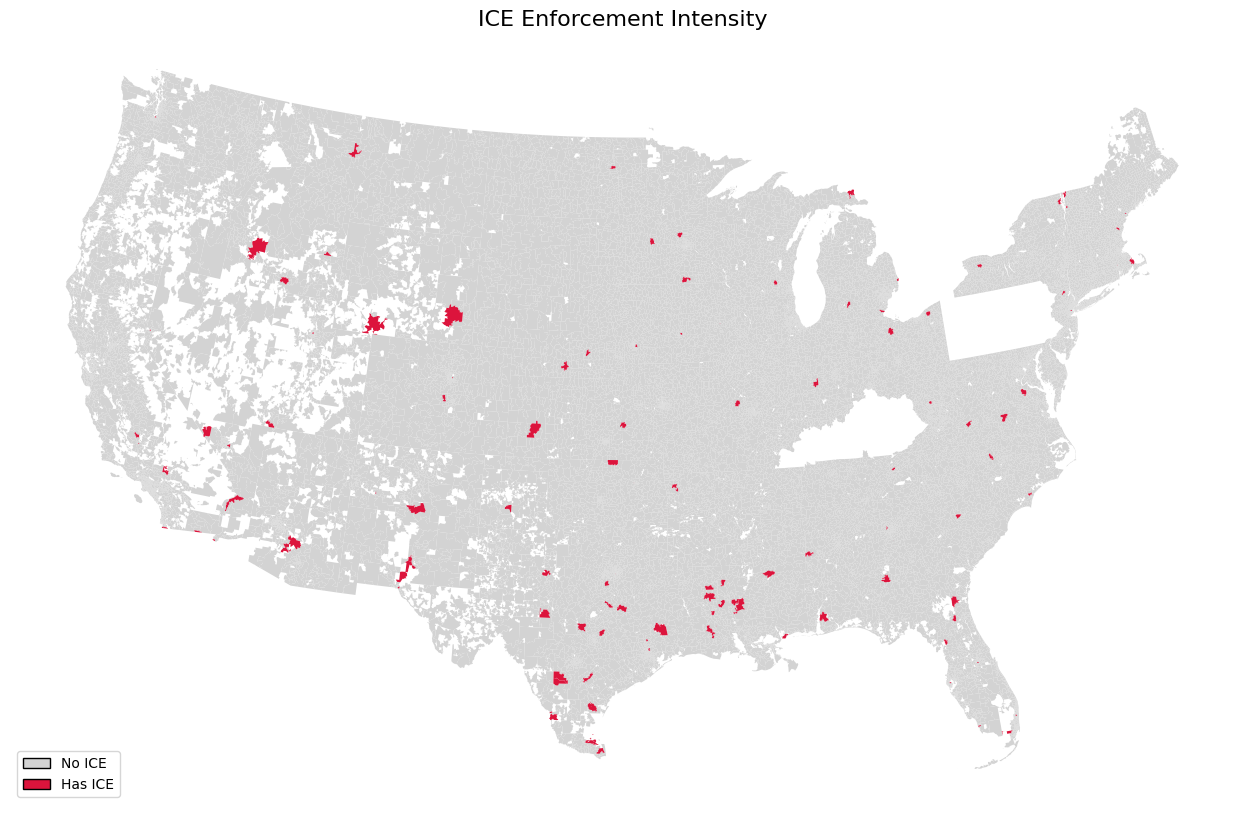

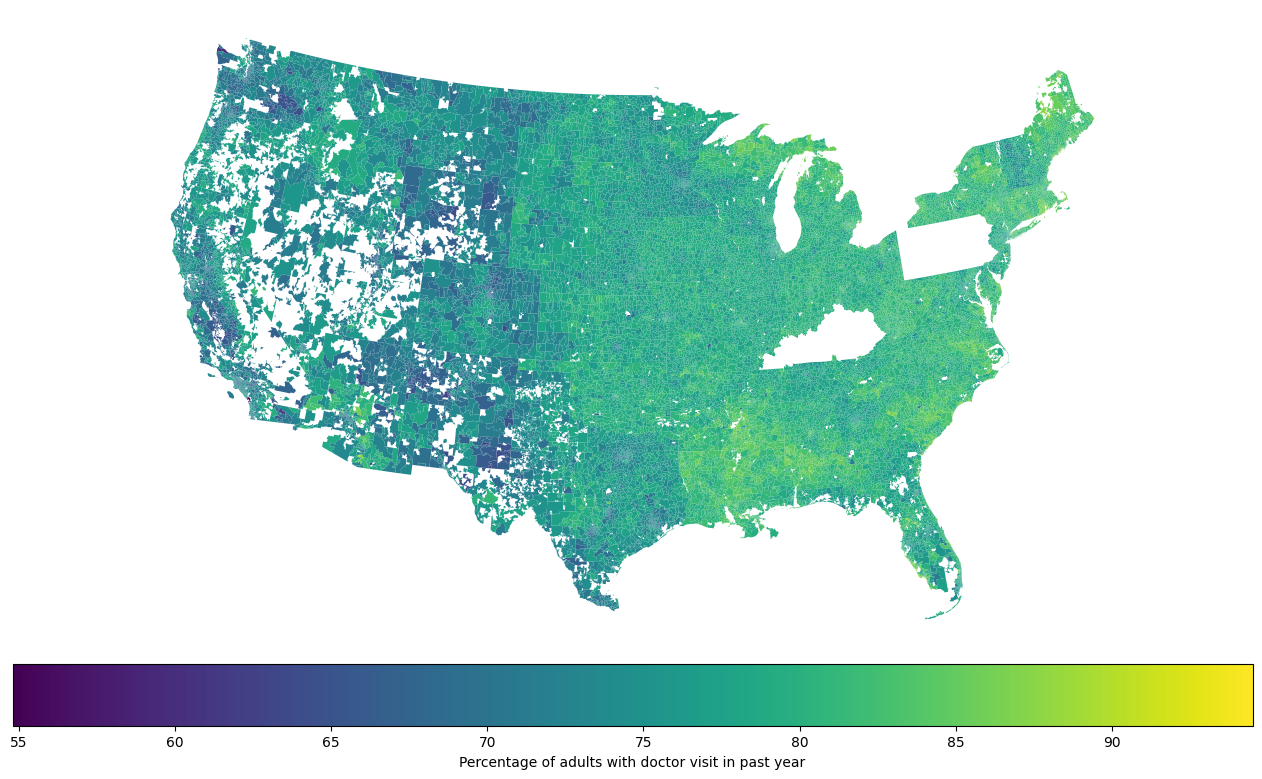

In [48]:
# 4. Figure 1: ICE Enforcement Intensity
gdf_final["ice_plot_val"] = gdf_final["average_daily_population"].fillna(0) + 0.1
vmax_ice = gdf_final["average_daily_population"].max()
# binary map: has ICE facility (average_daily_population > 0)
gdf_final['has_ice'] = (gdf_final['average_daily_population'] > 0).astype(int)

plt.figure(figsize=(16, 10))
ax1 = plt.gca()

# plot No-ICE first, then Has-ICE on top for clear contrast
gdf_final[gdf_final['has_ice'] == 0].plot(ax=ax1, color='lightgrey', linewidth=0)
gdf_final[gdf_final['has_ice'] == 1].plot(ax=ax1, color='crimson', linewidth=0)

# legend
ax1.legend(
    handles=[Patch(facecolor='lightgrey', edgecolor='k', label='No ICE'), Patch(facecolor='crimson', edgecolor='k', label='Has ICE')],
    loc='lower left'
)
ax1.set_title(f"ICE Enforcement Intensity", fontsize=16)
ax1.axis("off")

# plt.title(f"ICE Enforcement Intensity ({max_year})", fontsize=20)
plt.axis("off")

# SAVE INSTEAD OF SHOW
plt.savefig(os.path.join(image_dir, "map-ice-intensity.png"), dpi=300, bbox_inches="tight")
plt.show()

# 5. Figure 2: Healthcare Access
plt.figure(figsize=(16, 10))
ax2 = plt.gca()

gdf_final.plot(
    column="doctor_visits_past_year",
    ax=ax2,
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Percentage of adults with doctor visit in past year", "orientation": "horizontal", "pad": 0.02},
    linewidth=0
)

# plt.title(f"Percentage of Doctor Visits in Past Year ({max_year})", fontsize=20)
plt.axis("off")

# SAVE INSTEAD OF SHOW
plt.savefig(os.path.join(image_dir, "map-doctor-visits.png"), dpi=300, bbox_inches="tight")
plt.show()

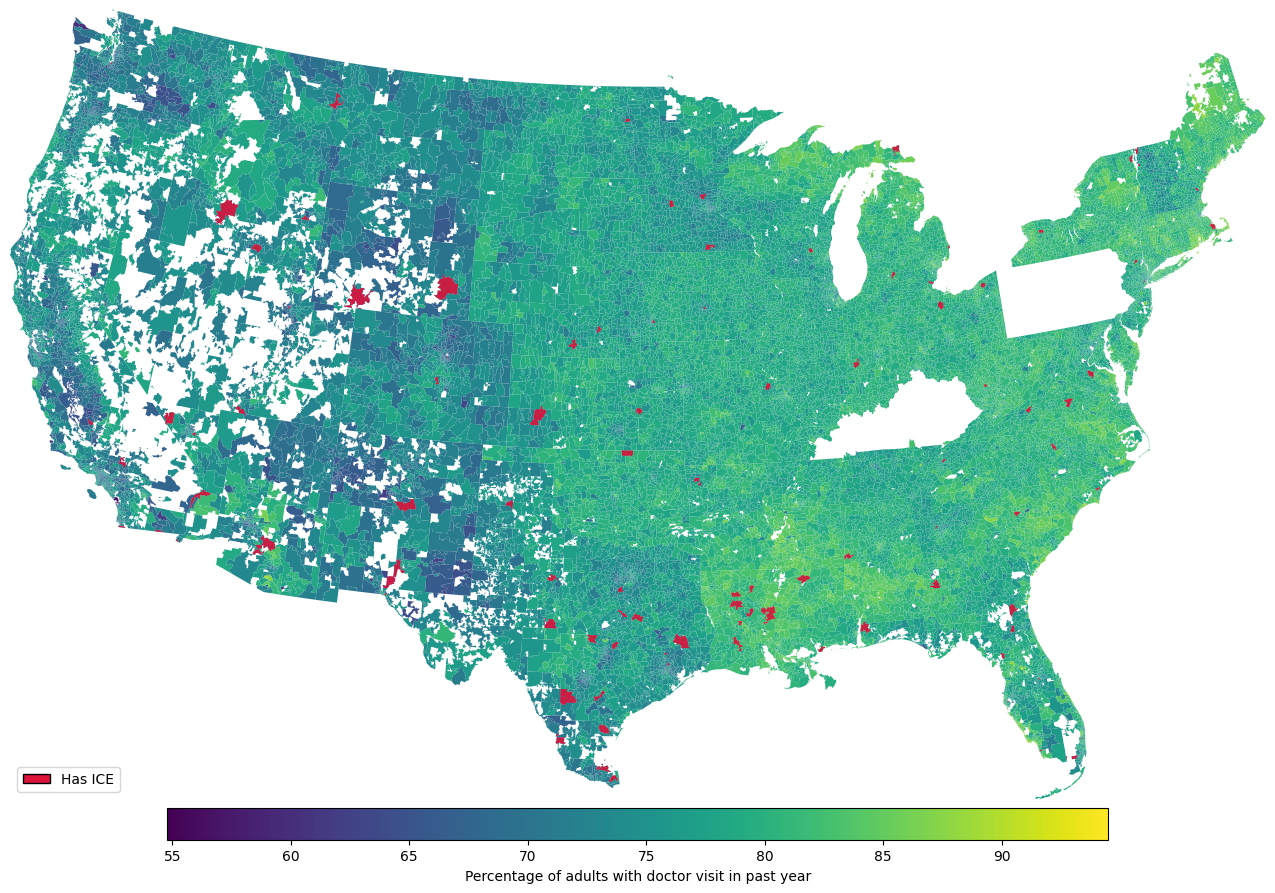

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

# Set consistent map bounds
bounds = gdf_final.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# Base choropleth: doctor visits
gdf_final.plot(
    column="doctor_visits_past_year",
    ax=ax,
    cmap="viridis",
    legend=True,
    legend_kwds={
        "label": "Percentage of adults with doctor visit in past year",
        "orientation": "horizontal",
        "pad": 0.01,
        "shrink": 0.6,
        "aspect": 30
    },
    linewidth=0,
    zorder=1
)

# Overlay: highlight ZCTAs with ICE facilities on top
gdf_final[gdf_final["has_ice"] == 1].plot(
    ax=ax,
    color="crimson",
    alpha=.9,
    linewidth=0,
    zorder=2
)

# Legend for ICE overlay
ax.legend(
    handles=[Patch(facecolor="crimson", edgecolor="k", label="Has ICE")],
    loc="lower left"
)

# ax.set_title("Doctor Visits (choropleth) with ICE Locations Overlaid", fontsize=16)
ax.axis("off")
ax.set_aspect("equal")

plt.subplots_adjust(left=0.01, right=0.99, top=0.95, bottom=0.01, wspace=0)
plt.savefig(os.path.join(image_dir, "map-ice-overlay-doctor-visits.png"), dpi=300, bbox_inches="tight")
plt.show()


## Average Doctor Visits
### Summary Statistics

In [50]:
df_merged[['doctor_visits_past_year']].describe()

,doctor_visits_past_year
count,185504.000000
mean,75.775621
std,4.658043
min,44.600000
25%,73.400000
50%,76.400000
75%,78.900000
max,95.800000


### Distribution of Doctor Visits Across Zipcodes

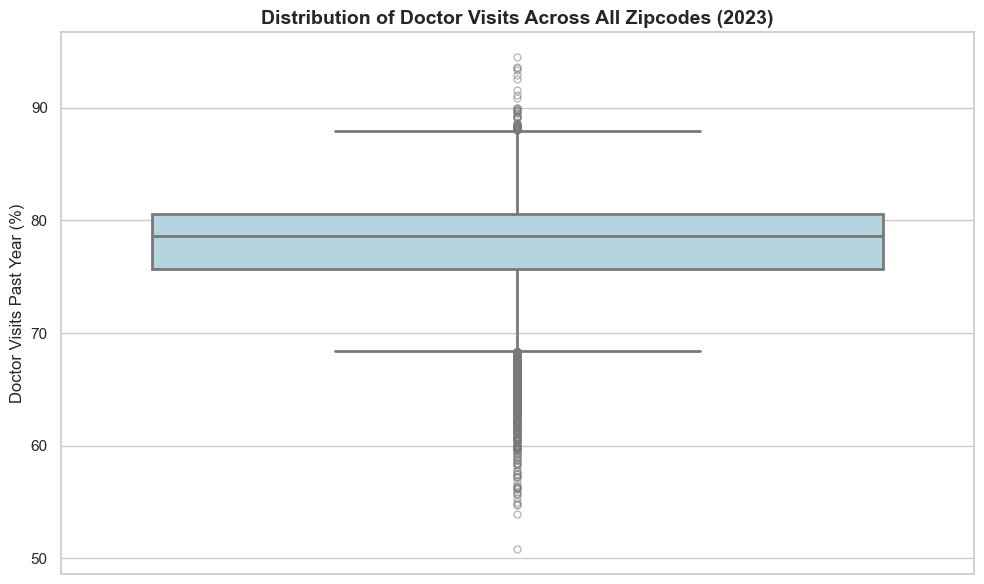

Total ZCTAs: 29983

Doctor Visits Rate Summary:
count    29983.000000
mean        77.833816
std          4.183079
min         50.800000
25%         75.700000
50%         78.600000
75%         80.600000
max         94.500000
Name: doctor_visits_past_year, dtype: float64


In [51]:
# 1. Work directly with places_zip_2023 (latest ZCTA data)
df_zip = places_zip_2023.copy()

# Standardize column names for consistency
df_zip = df_zip.clean_names().remove_empty()

# Rename data_value to doctor_visits_past_year for clarity
df_zip = df_zip.rename(columns={'data_value': 'doctor_visits_past_year'})

# 2. Box and whisker plot of doctor visits distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(
    data=df_zip,
    y='doctor_visits_past_year',
    color='lightblue',
    linewidth=2,
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.5}
)

# Formatting
plt.title('Distribution of Doctor Visits Across All Zipcodes (2023)', fontsize=14, fontweight='bold')
plt.ylabel('Doctor Visits Past Year (%)', fontsize=12)
plt.xlabel('')
plt.xticks([])

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "boxplot-doctor-visits.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3. Summary statistics
print(f"Total ZCTAs: {len(df_zip)}")
print(f"\nDoctor Visits Rate Summary:")
print(df_zip['doctor_visits_past_year'].describe())

### Scatter of Avg daily Detainees and Visits

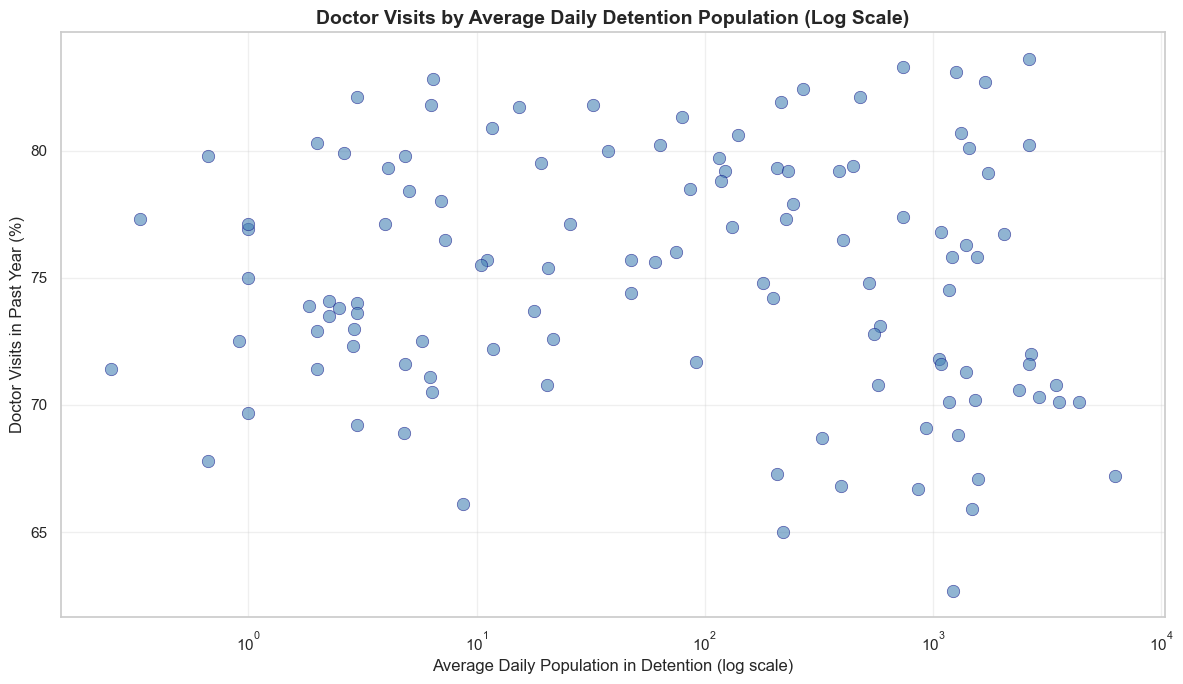

Total observations with detention data: 117

Correlation between doctor visits and detention population:
                          doctor_visits_past_year  average_daily_population
doctor_visits_past_year                  1.000000                 -0.225876
average_daily_population                -0.225876                  1.000000


In [52]:
# Filter for rows with detention data (non-zero and non-null average_daily_population)
df_scatter = df_merged[
    (df_merged['average_daily_population'] > 0) & 
    (df_merged['average_daily_population'].notna()) &
    (df_merged['year'] == df_merged['year'].max())
].copy()

# Create scatter plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_scatter,
    x='average_daily_population',
    y='doctor_visits_past_year',
    alpha=0.6,
    s=80,
    color='steelblue',
    edgecolor='navy',
    linewidth=0.5
)

# Formatting
plt.title('Doctor Visits by Average Daily Detention Population (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Population in Detention (log scale)', fontsize=12)
plt.ylabel('Doctor Visits in Past Year (%)', fontsize=12)

# Apply log scale to x-axis
plt.xscale('log')

# Add grid for readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "scatterplot-drvisits-vs-avg-dly-pop.png"), dpi=300, bbox_inches="tight")
plt.show()

# Summary statistics
print(f"Total observations with detention data: {len(df_scatter)}")
print(f"\nCorrelation between doctor visits and detention population:")
print(f"{df_scatter[['doctor_visits_past_year', 'average_daily_population']].corr()}")

### Doctor Visits by Hispanic Composition 

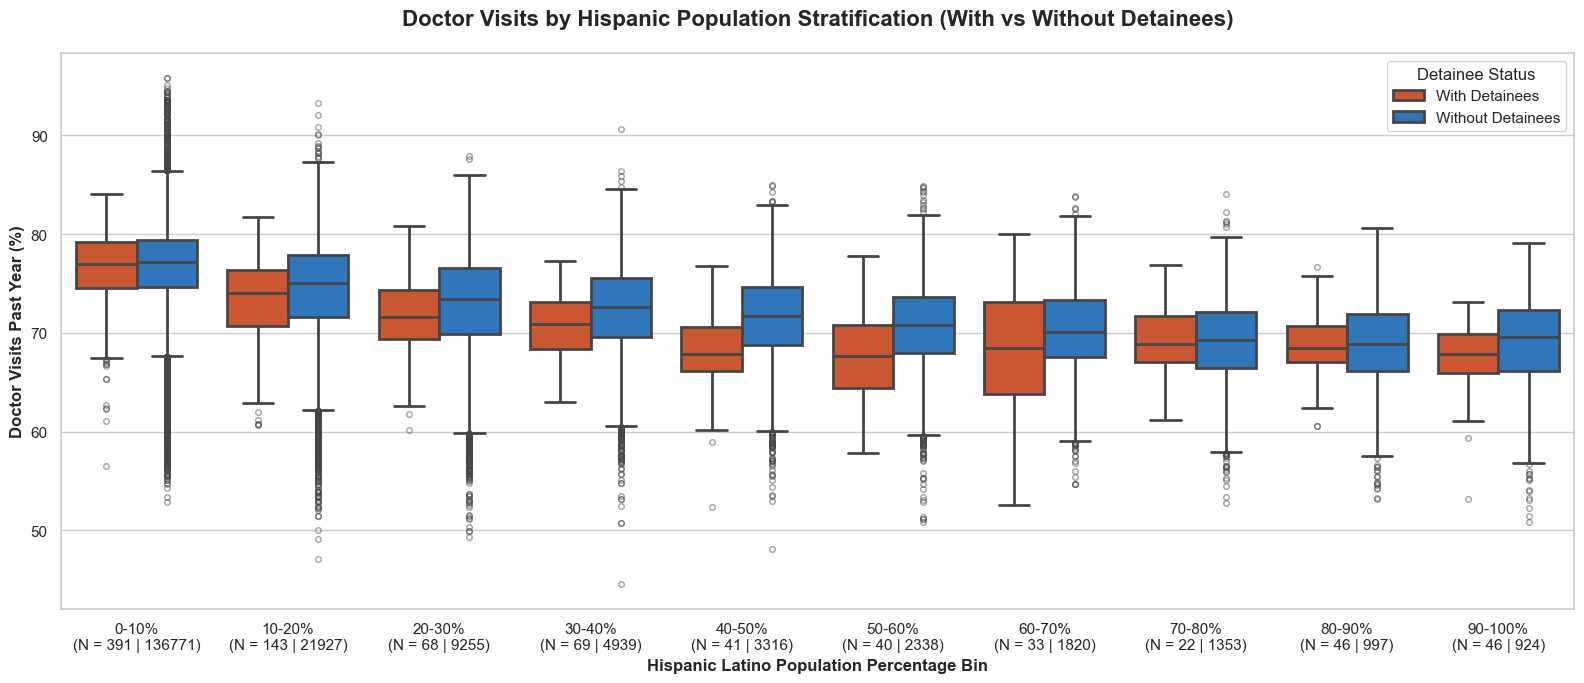

In [53]:
# Create two datasets from df_merged
# 1. With detainees: average_daily_population > 0
df_with_detainees = df_merged[
    (df_merged['average_daily_population'] > 0) & 
    (df_merged['average_daily_population'].notna()) &
    (df_merged['pct_hispanic_latino'].notna())
].copy()

# 2. Without detainees: average_daily_population is 0 or NA
df_without_detainees = df_merged[
    ((df_merged['average_daily_population'].isna()) | 
    (df_merged['average_daily_population'] == 0)) &
    (df_merged['doctor_visits_past_year'].notna()) &
    (df_merged['pct_hispanic_latino'].notna())
].copy()
df_without_detainees['average_daily_population'] = df_without_detainees['average_daily_population'].fillna(0)

# --- NEW: Add an identifier column and combine ---
df_with_detainees['Detainee Status'] = 'With Detainees'
df_without_detainees['Detainee Status'] = 'Without Detainees'
df_combined = pd.concat([df_with_detainees, df_without_detainees], ignore_index=True)

# Function to create combined stratified box plot
def create_combined_boxplot(df):
    # Create hispanic_strata with 10 bins
    df['hispanic_strata'] = pd.cut(
        df['pct_hispanic_latino'],
        bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1],
        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
        right=False
    )
    
    # Set the theme for a clean look
    sns.set_theme(style="whitegrid")
    
    # Define the order for the x-axis categories
    strata_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
    
    # Create a single figure and axis
    plt.figure(figsize=(16, 7))
    
    # Create the grouped boxplot using 'hue' to separate colors
    sns.boxplot(
        data=df,
        x='hispanic_strata',
        y='doctor_visits_past_year',
        hue='Detainee Status',        # Plots datasets side-by-side based on status
        order=strata_labels,          # Ensures categories appear in the correct order
        palette=['#E64A19', '#1976D2'], # Custom colors (e.g., Deep Orange and Blue)
        linewidth=2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )
    
    # Add titles and labels
    plt.title('Doctor Visits by Hispanic Population Stratification (With vs Without Detainees)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Hispanic Latino Population Percentage Bin', fontsize=12, fontweight='bold')
    plt.ylabel('Doctor Visits Past Year (%)', fontsize=12, fontweight='bold')
    
    # Add sample sizes (n=) to the x-tick labels for clarity (Showing both With / Without)
    new_labels = []
    for label in strata_labels:
        n_with = len(df[(df['hispanic_strata'] == label) & (df['Detainee Status'] == 'With Detainees')])
        n_without = len(df[(df['hispanic_strata'] == label) & (df['Detainee Status'] == 'Without Detainees')])
        new_labels.append(f"{label}\n(N = {n_with} | {n_without})")
        
    plt.xticks(ticks=range(len(strata_labels)), labels=new_labels)
    
    # Customize the legend position and title
    plt.legend(title='Detainee Status', loc='upper right')
    
    plt.tight_layout()
    plot_save_title = "boxplot-dr-visits-by-ha-pop-combined.png"
    plt.savefig(os.path.join(image_dir, plot_save_title), dpi=300, bbox_inches="tight")
    plt.show()

# Create the single combined plot
create_combined_boxplot(df_combined)

### Visits by Percentage Citizen Status

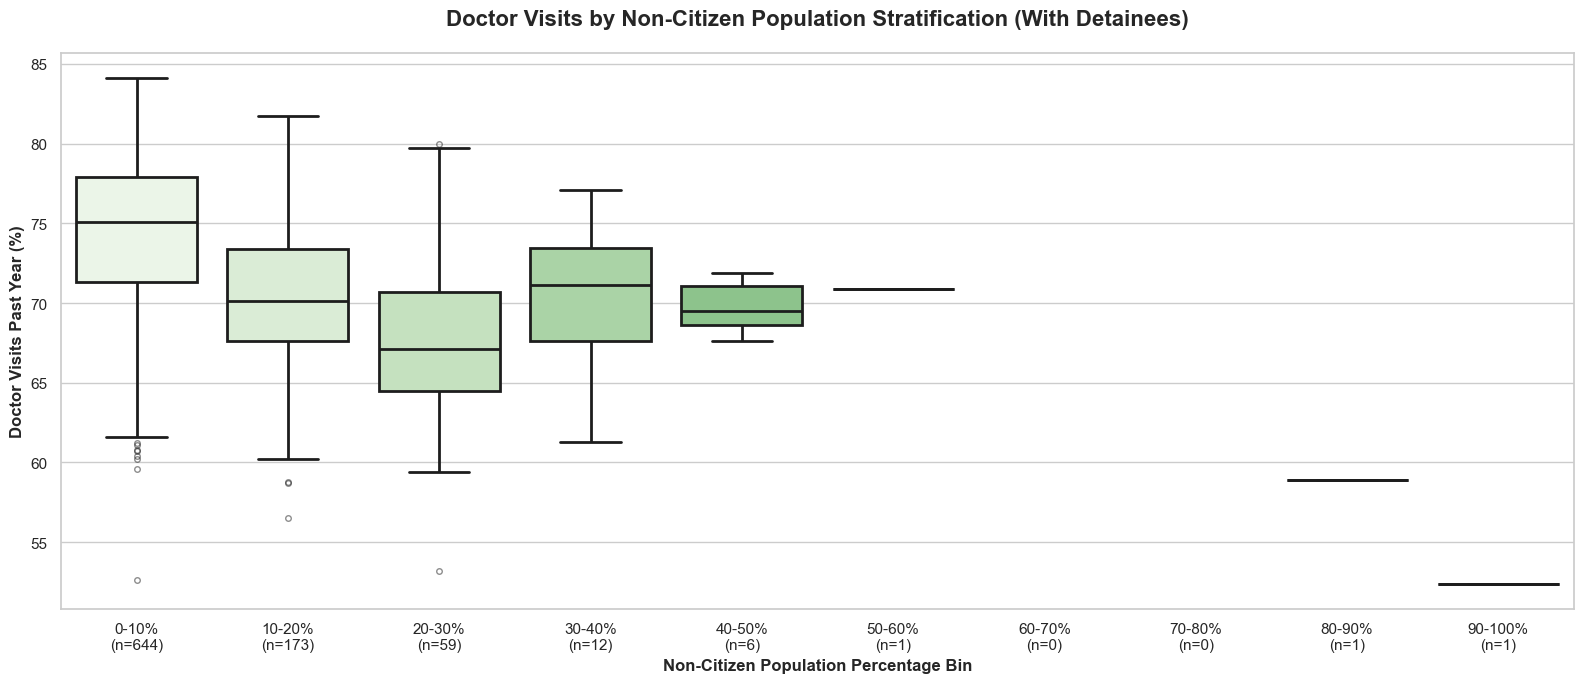

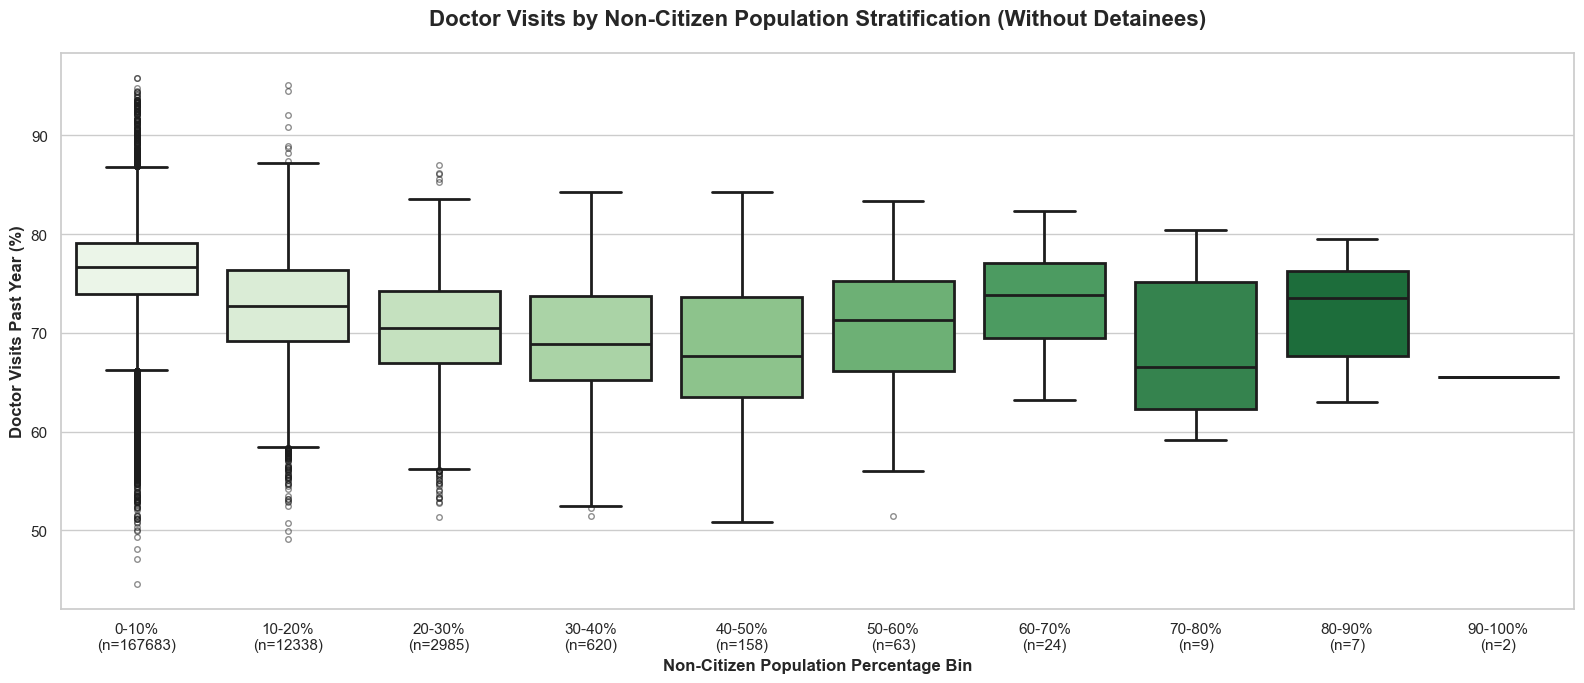

In [54]:
# Function to create stratified box plot for Non-Citizen Status
def create_citizen_stratified_boxplot(df, title_suffix):
    # Create citizen_strata with 10 bins
    df['citizen_strata'] = pd.cut(
        df['pct_non_citizen'],
        bins=[0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1],
        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'],
        right=False
    )
    
    # Set the theme for a clean look
    sns.set_theme(style="whitegrid")
    
    # Define the order for the x-axis categories
    strata_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
    
    # Create a single figure and axis
    plt.figure(figsize=(16, 7))
    
    # Create the boxplot on a single plane
    sns.boxplot(
        data=df,
        x='citizen_strata',
        y='doctor_visits_past_year',
        order=strata_labels,
        palette='Greens',      # Changed color to distinguish from the Hispanic plot
        linewidth=2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )
    
    # Add titles and labels
    plt.title(f'Doctor Visits by Non-Citizen Population Stratification ({title_suffix})', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Non-Citizen Population Percentage Bin', fontsize=12, fontweight='bold')
    plt.ylabel('Doctor Visits Past Year (%)', fontsize=12, fontweight='bold')
    
    # Add sample sizes (n=) to the x-tick labels for clarity
    counts = df['citizen_strata'].value_counts()
    new_labels = [f"{label}\n(n={counts.get(label, 0)})" for label in strata_labels]
    plt.xticks(ticks=range(len(strata_labels)), labels=new_labels)
    
    plt.tight_layout()
    plot_save_title = f"boxplot-dr-visits-by-citizen-status-{title_suffix.lower().replace(' ','-')}.png"
    plt.savefig(os.path.join(image_dir, plot_save_title), dpi=300, bbox_inches="tight")
    plt.show()

# Create plots for each dataset
create_citizen_stratified_boxplot(df_with_detainees, "With Detainees")
create_citizen_stratified_boxplot(df_without_detainees, "Without Detainees")

### Demographic Patterns in Care

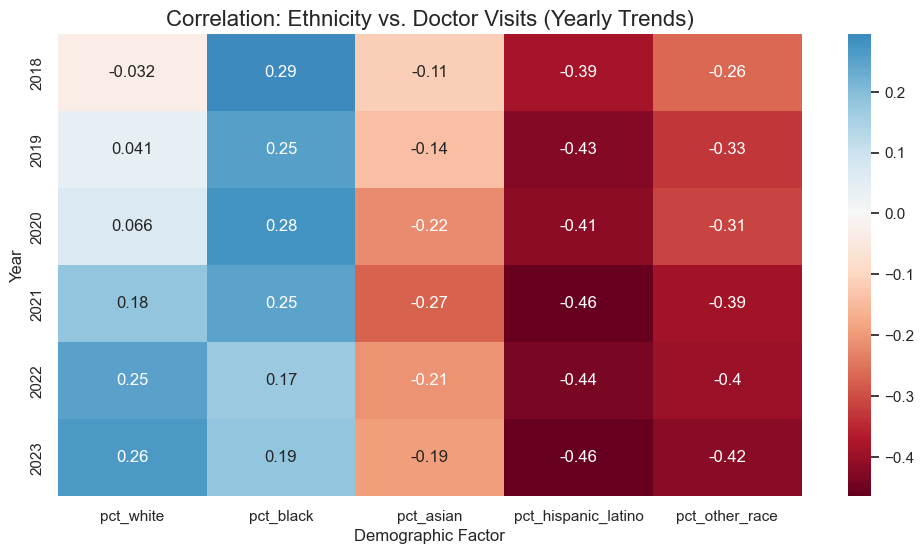

In [55]:
race_cols = ['pct_white', 'pct_black', 'pct_asian', 'pct_hispanic_latino', 'pct_other_race']
years = sorted(df_merged['year'].unique())
correlation_data = []

for yr in years:
    yearly_df = df_merged[df_merged['year'] == yr]
    corrs = yearly_df[race_cols + ['doctor_visits_past_year']].corr()['doctor_visits_past_year'].drop('doctor_visits_past_year')
    corrs.name = yr
    correlation_data.append(corrs)

# Combine into a single dataframe for heatmap
yearly_corr_df = pd.concat(correlation_data, axis=1).T

plt.figure(figsize=(12, 6))
sns.heatmap(yearly_corr_df, annot=True, cmap='RdBu', center=0)
plt.title('Correlation: Ethnicity vs. Doctor Visits (Yearly Trends)', fontsize=16)
plt.ylabel('Year')
plt.xlabel('Demographic Factor')
plt.savefig(os.path.join(image_dir, "corrplot-dr-visits-and-ethnicity.png"), dpi=300, bbox_inches="tight")
plt.show()

### Doctor Visits by Year

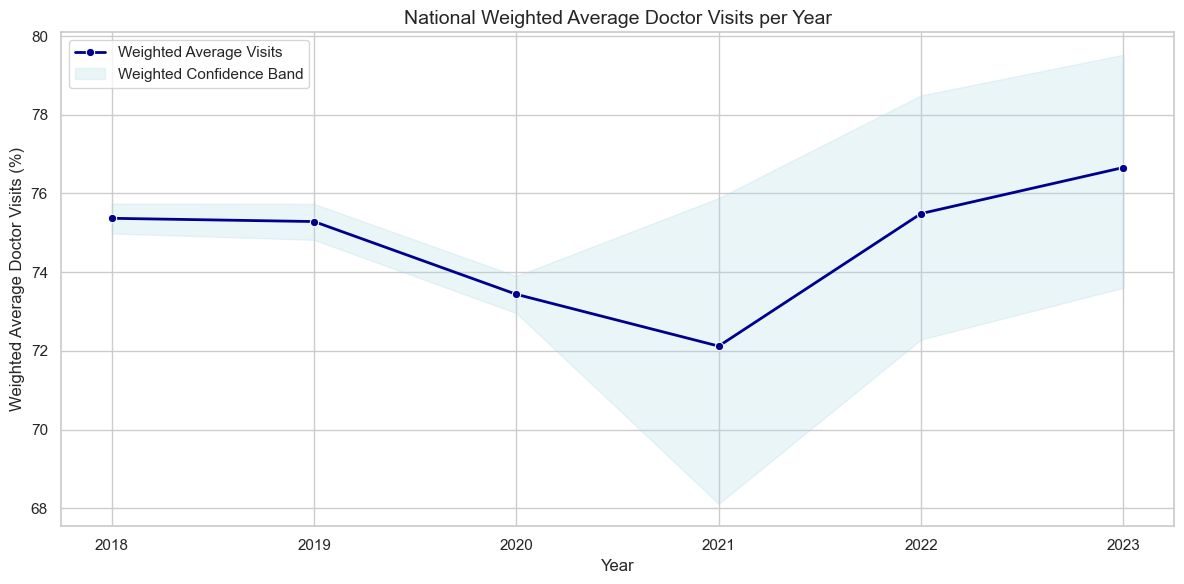

In [ ]:
# Convert percentage estimates into nominal counts using total population, then recompute the annual average.
df_merged['nominal_doctor_visits'] = df_merged['doctor_visits_past_year'] / 100 * df_merged['totalpopulation']

# Aggregate by year to compute the population-weighted average from nominal counts
df_yearly_weighted = (
    df_merged
    .groupby('year')
    .agg(
        total_population=('totalpopulation', 'sum'),
        total_visits=('nominal_doctor_visits', 'sum'),
        total_low=('nominal_low', 'sum'),
        total_high=('nominal_high', 'sum')
    )
    .reset_index()
)

df_yearly_weighted['weighted_avg'] = df_yearly_weighted['total_visits'] / df_yearly_weighted['total_population'] * 100
df_yearly_weighted['weighted_low'] = df_yearly_weighted['total_low'] / df_yearly_weighted['total_population'] * 100
df_yearly_weighted['weighted_high'] = df_yearly_weighted['total_high'] / df_yearly_weighted['total_population'] * 100

# Plot the annual weighted average with error bands
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_yearly_weighted,
    x='year',
    y='weighted_avg',
    marker='o',
    color='darkblue',
    linewidth=2,
    label='Weighted Average Visits'
)

plt.fill_between(
    df_yearly_weighted['year'],
    df_yearly_weighted['weighted_low'],
    df_yearly_weighted['weighted_high'],
    color='lightblue',
    alpha=0.25,
    label='Weighted Confidence Band'
)

# Formatting
plt.title('National Weighted Average Doctor Visits per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Average Doctor Visits (%)', fontsize=12)
plt.xticks(df_yearly_weighted['year'].unique())
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "lineplot-annual-dr-visits.png"), dpi=300, bbox_inches="tight")
plt.show()



### Doctor Visits by Economic Drivers 

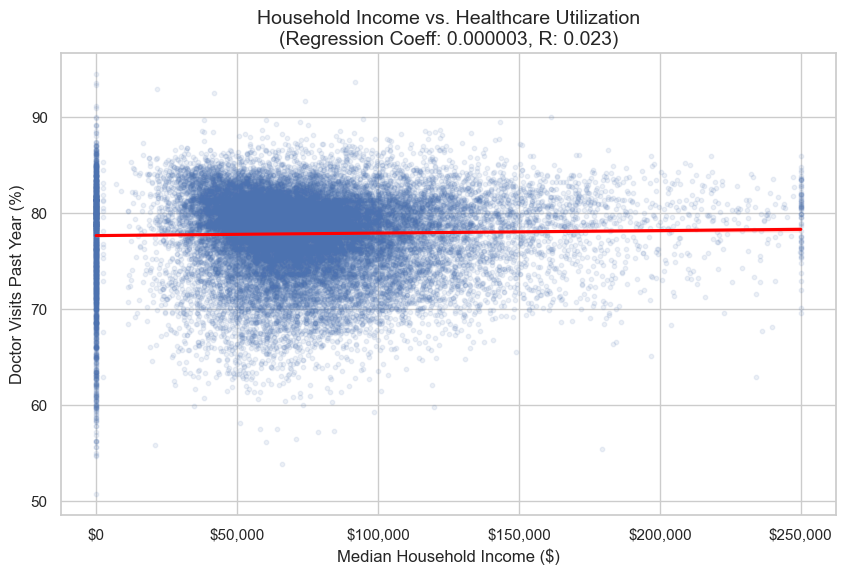

In [57]:
plt.figure(figsize=(10, 6))
# Calculate coefficient
mask = df_plot['median_household_income'].notna()
slope, intercept, r_val, p_val, std_err = stats.linregress(df_plot[mask]['median_household_income'], df_plot[mask]['doctor_visits_past_year'])

ax = sns.regplot(data=df_plot, x='median_household_income', y='doctor_visits_past_year', 
                 scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'red'})

# Formatting
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.title(f'Household Income vs. Healthcare Utilization\n(Regression Coeff: {slope:.6f}, R: {r_val:.3f})', fontsize=14)
plt.xlabel('Median Household Income ($)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-median-income.png"), dpi=300, bbox_inches="tight")
plt.show()

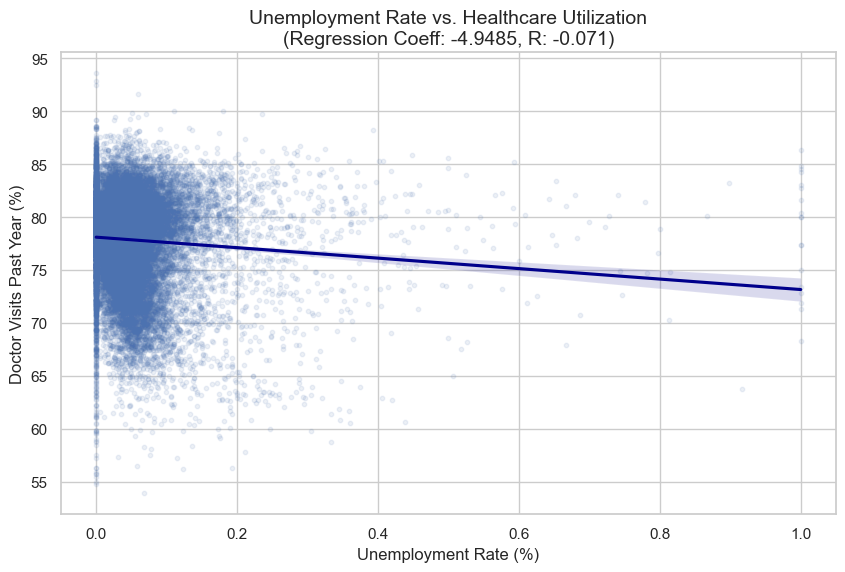

In [58]:
plt.figure(figsize=(10, 6))
# Calculate coefficient
mask = df_plot['pct_unemployed'].notna()
slope, intercept, r_val, p_val, std_err = stats.linregress(df_plot[mask]['pct_unemployed'], df_plot[mask]['doctor_visits_past_year'])

sns.regplot(data=df_plot, x='pct_unemployed', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'darkblue'})

plt.title(f'Unemployment Rate vs. Healthcare Utilization\n(Regression Coeff: {slope:.4f}, R: {r_val:.3f})', fontsize=14)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-enemployment-rate.png"), dpi=300, bbox_inches="tight")
plt.show()

### Impact of Educational Attainment on Doctor Visits

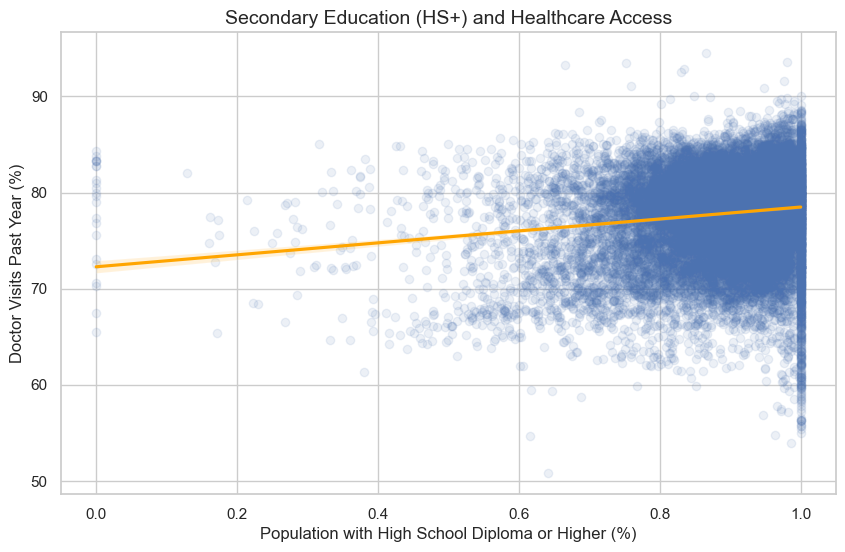

In [59]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='pct_high_school_or_higher', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'orange'})
plt.title('Secondary Education (HS+) and Healthcare Access', fontsize=14)
plt.xlabel('Population with High School Diploma or Higher (%)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-high-school-rate"), dpi=300, bbox_inches="tight")
plt.show()

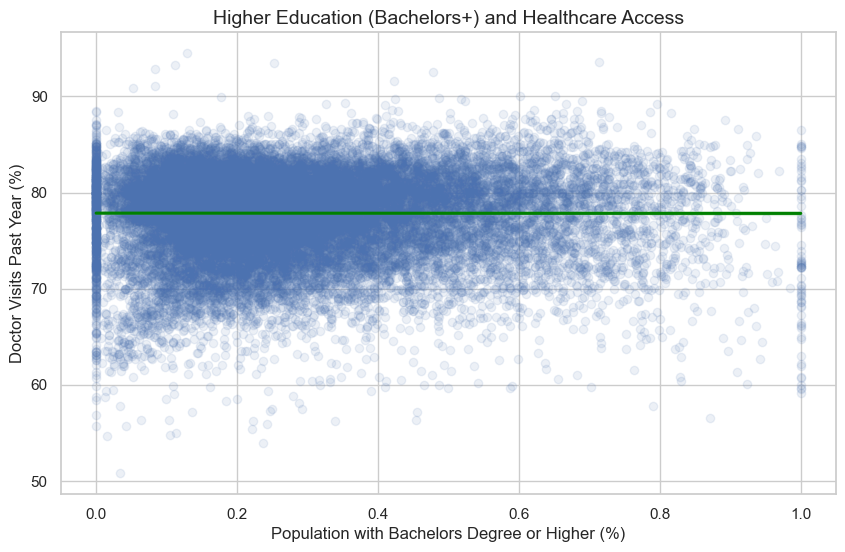

In [60]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='pct_bachelors_plus', y='doctor_visits_past_year', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'green'})
plt.title('Higher Education (Bachelors+) and Healthcare Access', fontsize=14)
plt.xlabel('Population with Bachelors Degree or Higher (%)')
plt.ylabel('Doctor Visits Past Year (%)')
plt.savefig(os.path.join(image_dir, "scatterplot-visits-vs-bach-rate"), dpi=300, bbox_inches="tight")
plt.show()

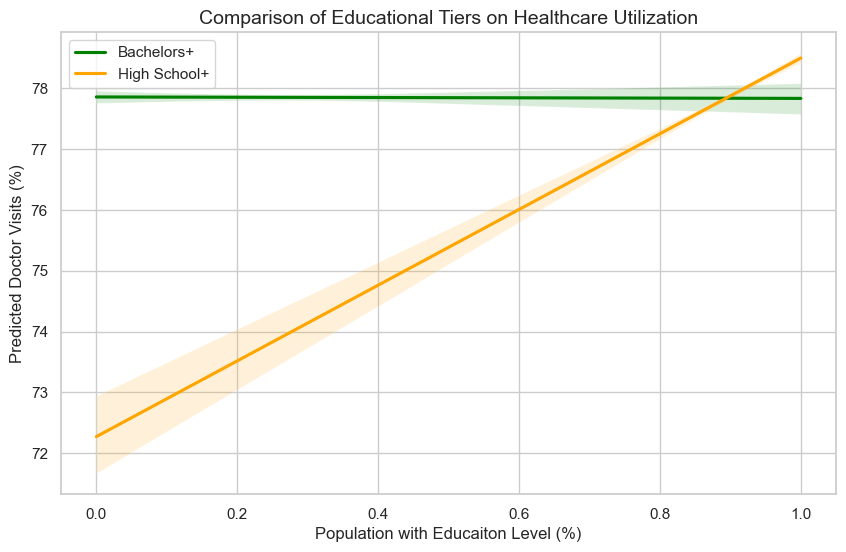

In [61]:
plt.figure(figsize=(10, 6))
# Plotting both lines without scatter to show the "slope" difference clearly
sns.regplot(data=df_plot, x='pct_bachelors_plus', y='doctor_visits_past_year', 
            scatter=False, label='Bachelors+', color='green')
sns.regplot(data=df_plot, x='pct_high_school_or_higher', y='doctor_visits_past_year', 
            scatter=False, label='High School+', color='orange')
plt.title('Comparison of Educational Tiers on Healthcare Utilization', fontsize=14)
plt.legend()
plt.ylabel('Predicted Doctor Visits (%)')
plt.xlabel('Population with Educaiton Level (%)')
plt.savefig(os.path.join(image_dir, "regressionplot-visits-vs-education.png"), dpi=300, bbox_inches="tight")
plt.show()

## Average Daily Detanees
### Detainees over the years

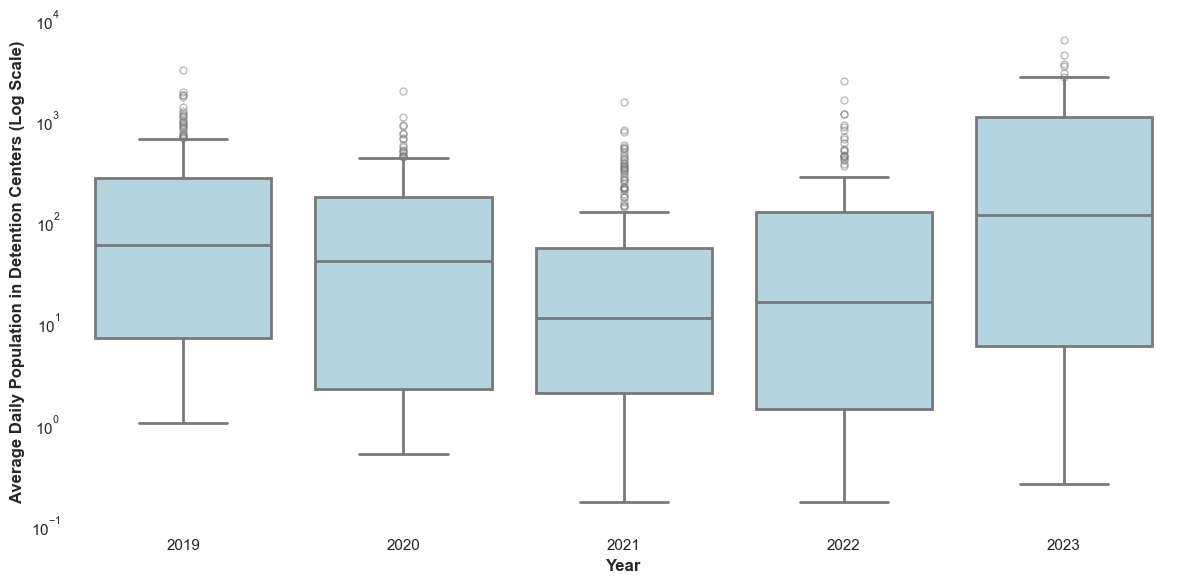

In [62]:
# Ensure we only have positive values for the log scale
detainee_df = df_merged[
    (df_merged['average_daily_population'] > 0) &
    (df_merged['average_daily_population'].notna())
].copy()

# Create a box and whisker plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=detainee_df,
    x='year',
    y='average_daily_population',
    color='lightblue',
    linewidth=2,
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.5}
)

plt.grid(False)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Apply logarithmic scale to the y-axis
plt.yscale('log')

# Update titles and labels to reflect the log scale
# plt.title('Average Daily Population Distribution by Year (Log Scale)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Population in Detention Centers (Log Scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(image_dir, "boxplot-avg-dly-pop-per-year.png"), dpi=300, bbox_inches="tight")
plt.show()

## Correlation Plots

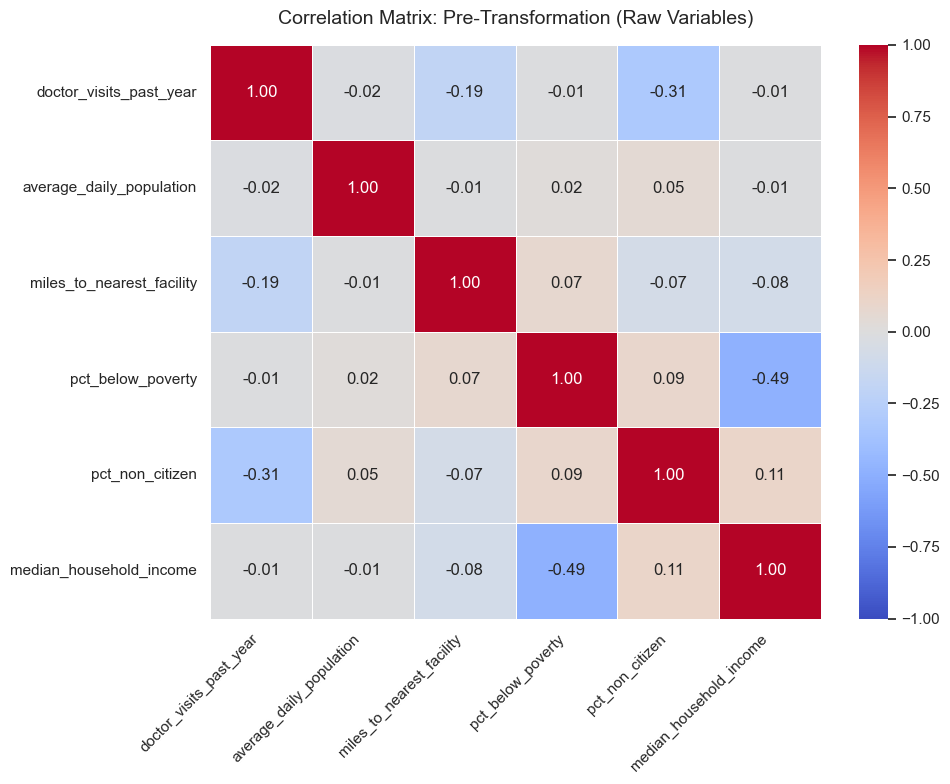

In [63]:
# Define your primary outcome variable
outcome_var = 'doctor_visits_past_year' 

# Define the variables for the "Pre" state (Raw, highly skewed)
cols_pre = [
    outcome_var, 
    'average_daily_population', 
    'miles_to_nearest_facility', 
    'pct_below_poverty', 
    'pct_non_citizen', 
    'median_household_income'
]

# Calculate the Pearson correlation matrix
corr_pre = df_merged[cols_pre].corr()

# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pre, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=0.5)

# Formatting
plt.title('Correlation Matrix: Pre-Transformation (Raw Variables)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save the figure for your thesis write-up
plt.savefig('final-images/correlation_pre_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

# Data Transformation
Using what we've observed in the above EDA, we'll modify our variables to:
1. Handle missing data
2. Address Skewness
3. Create a variable for if a zip has a detention center or not

In [64]:
print("Starting data transformations...")

# 1. IMPUTE MISSING CENSUS DATA
# Fill missing numeric values with the median of their respective columns
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols] = df_merged[numeric_cols].fillna(df_merged[numeric_cols].median())

# 2. CREATE BINARY TREATMENT INDICATORS
# 99.5% of zip codes have 0 detainees. This binary flag is much better for inferential modeling.
df_merged['has_ice_facility'] = (df_merged['average_daily_population'] > 0).astype(int)

# 3. LOG TRANSFORMATIONS FOR HIGHLY SKEWED VARIABLES
# log1p safely applies natural log to variables that contain zeros (log(1 + x))

# Fix the 11.3 skewness in distance
df_merged['log_miles_to_facility'] = np.log1p(df_merged['miles_to_nearest_facility'])

# Normalize the extreme outliers in population for the 0.5% of zips that actually have facilities
df_merged['log_average_daily_population'] = np.log1p(df_merged['average_daily_population'])

# 4. (Optional) DROP EXTREME SPATIAL OUTLIERS
# If that 5,227 mile max distance is throwing off mainland US analysis, cap it or drop it.
# Un-comment the line below to drop non-contiguous US outliers (e.g., keeping only < 3000 miles)
# df_merged = df_merged[df_merged['miles_to_nearest_facility'] < 3000]

print("Transformations complete. Ready for modeling.")

# Check the new skewed metrics
print("\nNew Skewness Profile:")
print(df_merged[['log_miles_to_facility', 'log_average_daily_population', 'has_ice_facility']].skew())

Starting data transformations...
Transformations complete. Ready for modeling.

New Skewness Profile:
log_miles_to_facility           -0.424970
log_average_daily_population    19.486556
has_ice_facility                14.260189
dtype: float64


In [65]:
# Export df_merged to CSV for reference in report
df_merged.to_csv('Data/panel_data2.csv', index=False)

Recreating our correlation matrix after the data transformation

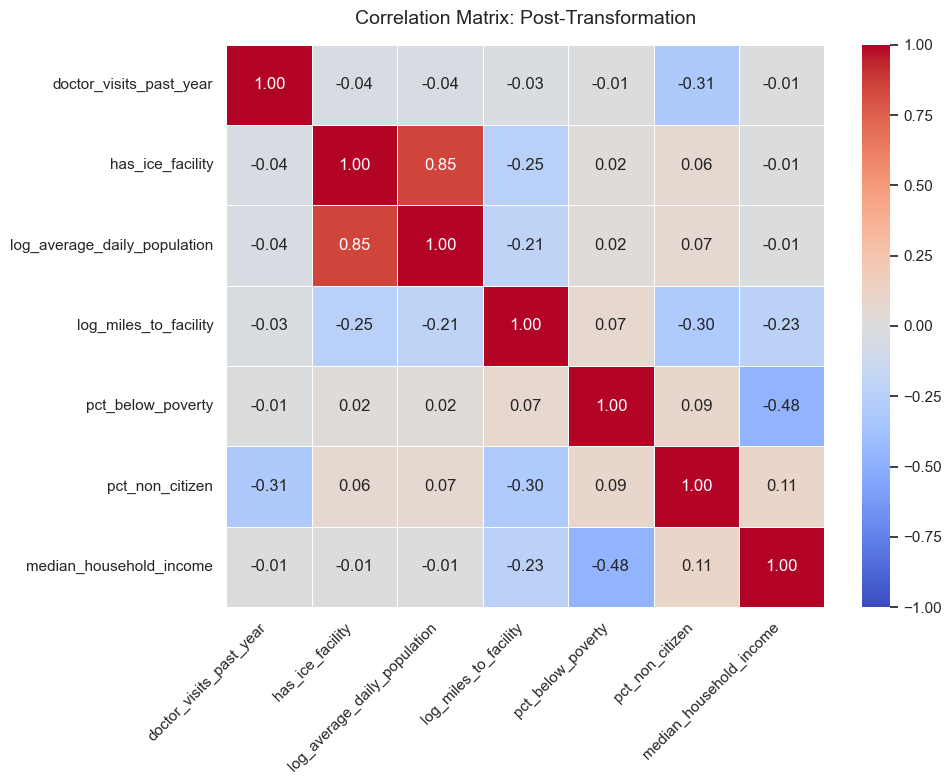

In [66]:
# Define the variables for the "Post" state (Binary flags and Log-transformed)
cols_post = [
    outcome_var, 
    'has_ice_facility', 
    'log_average_daily_population',
    'log_miles_to_facility', 
    'pct_below_poverty', 
    'pct_non_citizen', 
    'median_household_income'
]

# Calculate the Pearson correlation matrix
corr_post = df_merged[cols_post].corr()

# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_post, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=0.5)

# Formatting
plt.title('Correlation Matrix: Post-Transformation', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save the figure for your thesis write-up
plt.savefig('final-images/correlation_post_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

Compare the pre and post correlation matrix

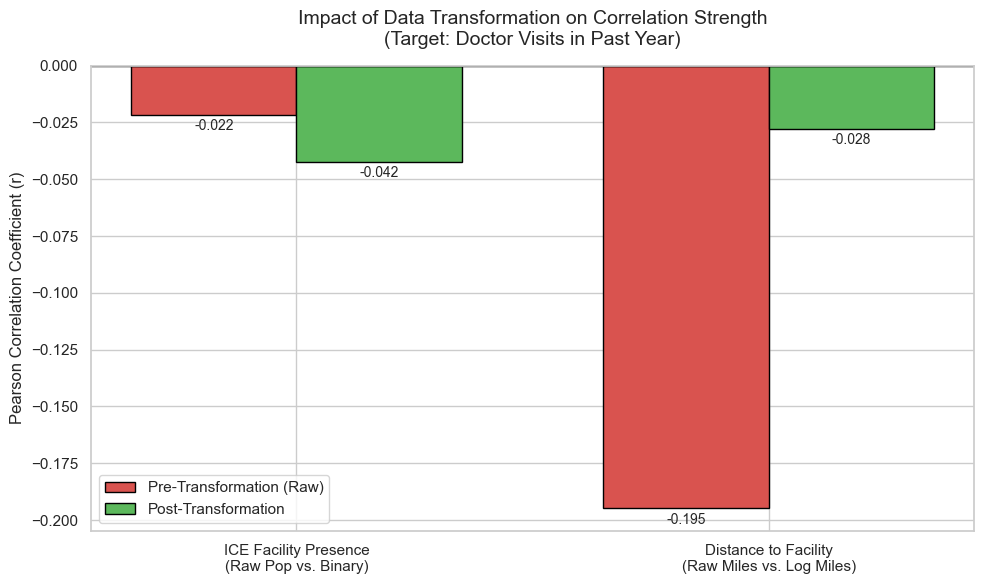

In [67]:
# 1. Calculate the correlations for the ICE metrics against the outcome variable
# PRE (Raw)
corr_raw_pop = df_merged[outcome_var].corr(df_merged['average_daily_population'])
corr_raw_dist = df_merged[outcome_var].corr(df_merged['miles_to_nearest_facility'])

# POST (Transformed - Using Binary for Population and Log for Distance)
corr_bin_pop = df_merged[outcome_var].corr(df_merged['has_ice_facility'])
corr_log_dist = df_merged[outcome_var].corr(df_merged['log_miles_to_facility'])

# 2. Set up the bar chart
labels = ['ICE Facility Presence\n(Raw Pop vs. Binary)', 'Distance to Facility\n(Raw Miles vs. Log Miles)']
pre_corrs = [corr_raw_pop, corr_raw_dist]
post_corrs = [corr_bin_pop, corr_log_dist]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars
rects1 = ax.bar(x - width/2, pre_corrs, width, label='Pre-Transformation (Raw)', color='#d9534f', edgecolor='black')
rects2 = ax.bar(x + width/2, post_corrs, width, label='Post-Transformation', color='#5cb85c', edgecolor='black')

# Formatting the chart
ax.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12)
ax.set_title('Impact of Data Transformation on Correlation Strength\n(Target: Doctor Visits in Past Year)', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

# Add a horizontal line at 0 for visual grounding
ax.axhline(0, color='black', linewidth=1)

# Add the exact numbers on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=10)
ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=10)

plt.tight_layout()

# Save and display
plt.savefig('final-images/correlation_comparison_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Modeling
To isolate the relationship between immigration enforcement infrastructure and healthcare utilization, this study employs a Two-Way Fixed Effects (TWFE) panel regression model. Relying on cross-sectional OLS would introduce severe omitted variable bias, as unobserved local characteristics—such as historical health infrastructure, community trust, or local political climates—heavily influence both ICE facility placement and healthcare behavior.

By leveraging panel data from 2018 to 2023, the TWFE model includes ZIP code-level fixed effects to absorb all time-invariant geographic and demographic heterogeneity. Additionally, year fixed effects are included to control for macro-level shocks affecting all ZIP codes simultaneously, most notably the COVID-19 pandemic and national federal policy shifts. The resulting coefficients represent the within-ZIP variation: how changes in ICE presence or distance relative to a ZIP code's own baseline affect the local rate of routine doctor visits. Standard errors are clustered at the ZIP code level to account for serial autocorrelation.

## Checking assumpitions for TWFE

--- ASSUMPTION 1: WITHIN-UNIT VARIATION ---
Never Treated (Control Group): 32613 ZIPs
Always Treated (Absorbed by FE): 0 ZIPs
Switchers (The ones driving your Model 1 results): 364 ZIPs

--- ASSUMPTION 2: PARALLEL TRENDS (EVENT STUDY) ---


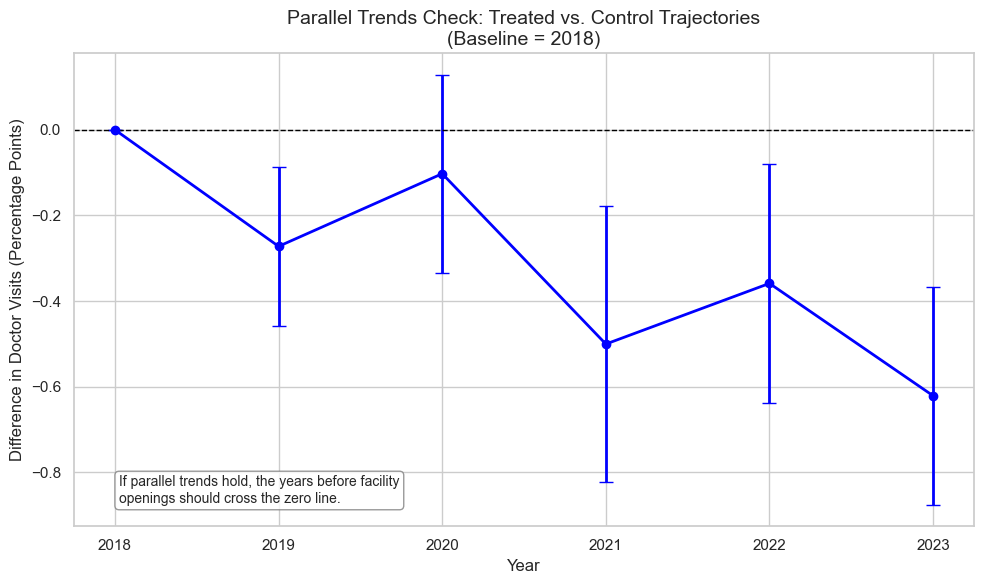


Event Study Interaction Coefficients:
                                     Parameter Estimates                                     
                           Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------------
const                         73.603     2.7238     27.022     0.0000      68.265      78.942
pct_white                     2.1085     2.7142     0.7768     0.4373     -3.2113      7.4283
pct_black                     2.7925     2.7059     1.0320     0.3021     -2.5111      8.0961
pct_asian                     0.3548     2.7518     0.1289     0.8974     -5.0387      5.7483
pct_hispanic_latino          -0.3665     0.2134    -1.7173     0.0859     -0.7847      0.0518
pct_two_plus                  0.5924     2.7248     0.2174     0.8279     -4.7482      5.9330
pct_other_race                1.4364     2.7253     0.5270     0.5982     -3.9053      6.7780
pct_non_citizen      

In [68]:
# ==========================================
# TWFE ASSUMPTION CHECKS
# ==========================================

print("--- ASSUMPTION 1: WITHIN-UNIT VARIATION ---")
# Calculate how many years each zip code had a facility
treatment_counts = df_merged.groupby('zcta5')['has_ice_facility'].sum()

never_treated = (treatment_counts == 0).sum()
always_treated = (treatment_counts == df_merged['year'].nunique()).sum()
switchers = ((treatment_counts > 0) & (treatment_counts < df_merged['year'].nunique())).sum()

print(f"Never Treated (Control Group): {never_treated} ZIPs")
print(f"Always Treated (Absorbed by FE): {always_treated} ZIPs")
print(f"Switchers (The ones driving your Model 1 results): {switchers} ZIPs")

if switchers < 10:
    print("\nWARNING: You have very few ZIPs that opened/closed facilities. Model 1 is relying on a tiny sample of variation!")


print("\n--- ASSUMPTION 2: PARALLEL TRENDS (EVENT STUDY) ---")
# To test parallel trends, we interact the treatment group with the Year dummies.
# If the parallel trends assumption holds, the coefficients for the years PRIOR to 
# an ICE facility opening should be statistically insignificant (meaning they were trending together).

# Create a master flag for "Ever Treated" (Did this zip code ever have a facility?)
df_merged['ever_treated'] = df_merged.groupby('zcta5')['has_ice_facility'].transform('max')

# Create Year Dummy Interactions with the 'ever_treated' group
# We use 2018 as the baseline omitted year to avoid perfect multicollinearity
years = sorted(df_merged['year'].unique())
interaction_cols = []

for y in years[1:]: # Skip 2018 (baseline)
    col_name = f'treated_x_year_{y}'
    df_merged[col_name] = df_merged['ever_treated'] * (df_merged['year'] == y).astype(int)
    interaction_cols.append(col_name)

# Set up the panel dataframe again
df_panel_check = df_merged.set_index(['zcta5', 'year'])

# Run the Event Study Regression
# We regress doctor visits on our controls + the year dummies + the interaction terms
controls = [
    'pct_white', 
    'pct_black', 
    'pct_asian', 
    'pct_hispanic_latino', 
    'pct_two_plus', 
    'pct_other_race',
    'pct_non_citizen',
    'pct_below_poverty',
    'pct_unemployed',
    'pct_high_school_or_higher',
    'pct_rent_burdened_30_plus',
    'pct_no_internet',
    'pct_no_vehicle'
    ]
exog_event = sm.add_constant(df_panel_check[controls + interaction_cols])

mod_event = PanelOLS(df_panel_check['doctor_visits_past_year'], exog_event, entity_effects=True, time_effects=True)
res_event = mod_event.fit(cov_type='clustered', cluster_entity=True)

# Extract coefficients and confidence intervals for the interaction terms to plot them
params = res_event.params[interaction_cols]
conf_int = res_event.conf_int().loc[interaction_cols]
errors = params - conf_int['lower']

# Plot the Parallel Trends / Event Study
plt.figure(figsize=(10, 6))

# Add the baseline year (2018) at zero
plot_years = years
plot_params = [0] + list(params.values)
plot_errors = [0] + list(errors.values)

plt.errorbar(plot_years, plot_params, yerr=plot_errors, fmt='o-', capsize=5, color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(plot_years)
plt.title('Parallel Trends Check: Treated vs. Control Trajectories\n(Baseline = 2018)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Difference in Doctor Visits (Percentage Points)', fontsize=12)

# Add a note explaining interpretation
plt.annotate('If parallel trends hold, the years before facility\nopenings should cross the zero line.', 
             xy=(0.05, 0.05), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig('Data/parallel_trends_event_study.png', dpi=300)
plt.show()

# Print the formal table
print("\nEvent Study Interaction Coefficients:")
print(res_event.summary.tables[1])

The event study specification reveals a persistent negative divergence in healthcare utilization for treated ZIP codes relative to the 2018 baseline. Notably, the treatment effect becomes statistically indistinguishable from zero in 2020 (p=0.316), reflecting the universal suspension of routine medical care during the onset of the COVID-19 pandemic. In the post-lockdown recovery period (2021-2023), the negative divergence reappears and deepens, suggesting that the chilling effect of local ICE infrastructure heavily suppressed the return to routine healthcare.

## Building our models

In [69]:
print("Prepping data for Panel OLS...")

# 1. Panel data requires a MultiIndex of (Entity, Time)
# Set zcta5 and year as the index
df_panel = df_merged.set_index(['zcta5', 'year'])

# 2. Define the dependent variable and the control variables
dependent = df_panel['doctor_visits_past_year']

# Using the variables cleared in the VIF check
controls = [
    'pct_below_poverty', 
    'pct_non_citizen', 
    'median_household_income',
    'pct_white',
    'pct_bachelors_plus',
    'pct_unemployed'
]

all_controls = [
    'pct_white', 
    'pct_black', 
    'pct_asian', 
    'pct_hispanic_latino', 
    'pct_two_plus', 
    'pct_other_race',
    'pct_non_citizen',
    'pct_below_poverty',
    'pct_unemployed',
    'pct_high_school_or_higher',
    'pct_rent_burdened_30_plus',
    'pct_no_internet',
    'pct_no_vehicle'
    ]

# statsmodels requires an explicit constant (intercept)
exog_controls = sm.add_constant(df_panel[all_controls])

# ---------------------------------------------------------
# MODEL 1: The Local Effect (Binary ICE Presence)
# ---------------------------------------------------------
print("\nFitting Model 1: Local Effect (Binary Presence)...")
exog_m1 = exog_controls.copy()
exog_m1['has_ice_facility'] = df_panel['has_ice_facility']

# ADDED drop_absorbed=True
mod_1 = PanelOLS(dependent, exog_m1, entity_effects=True, time_effects=True, drop_absorbed=True)
res_1 = mod_1.fit(cov_type='clustered', cluster_entity=True)


# ---------------------------------------------------------
# MODEL 2: The Chilling Effect (Distance to Nearest Facility)
# ---------------------------------------------------------
print("Fitting Model 2: Chilling Effect (Log Distance)...")
exog_m2 = exog_controls.copy()
exog_m2['log_miles_to_facility'] = df_panel['log_miles_to_facility']

# Fix: Set entity_effects=False so the static distance variable isn't absorbed
mod_2 = PanelOLS(dependent, exog_m2, entity_effects=False, time_effects=True, drop_absorbed=True)
res_2 = mod_2.fit(cov_type='clustered', cluster_entity=True)

# ---------------------------------------------------------
# MODEL 3: Regional Chilling Effect (<= 50 Miles)
# ---------------------------------------------------------
print("Fitting Model 3: Regional Chilling Effect (<= 50 Miles)...")
df_panel['facility_within_50m'] = (df_panel['miles_to_nearest_facility'] <= 50).astype(int)
exog_m3 = exog_controls.copy()
exog_m3['facility_within_50m'] = df_panel['facility_within_50m']

# FIX: Set entity_effects=False because the 50-mile threshold is currently a static geographic variable
mod_3 = PanelOLS(dependent, exog_m3, entity_effects=False, time_effects=True, drop_absorbed=True)
res_3 = mod_3.fit(cov_type='clustered', cluster_entity=True)

Prepping data for Panel OLS...

Fitting Model 1: Local Effect (Binary Presence)...
Fitting Model 2: Chilling Effect (Log Distance)...
Fitting Model 3: Regional Chilling Effect (<= 50 Miles)...


## Model results

In [70]:
def extract_main_effects(results, treatment_var):
    coef = results.params[treatment_var]
    p_val = results.pvalues[treatment_var]
    ci_lower = results.conf_int().loc[treatment_var, 'lower']
    ci_upper = results.conf_int().loc[treatment_var, 'upper']
    
    print(f"Variable: {treatment_var}")
    print(f"Coefficient: {coef:.4f}")
    print(f"P-value: {p_val:.4f}")
    print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]\n")

print("--- MODEL 1: BINARY ICE PRESENCE ---")
extract_main_effects(res_1, 'has_ice_facility')

print("--- MODEL 2: DISTANCE TO ICE FACILITY ---")
extract_main_effects(res_2, 'log_miles_to_facility')

print("--- MODEL 3: REGIONAL ICE PRESENCE (<= 50 MILES) ---")
extract_main_effects(res_3, 'facility_within_50m')

def check_model_fit(results, model_name):
    print(f"--- {model_name} FIT METRICS ---")
    print(f"R-squared (Within):  {results.rsquared_within:.4f}")
    print(f"R-squared (Overall): {results.rsquared_overall:.4f}")
    print(f"Observations used:   {results.nobs}\n")

check_model_fit(res_1, "MODEL 1")
check_model_fit(res_2, "MODEL 2")
check_model_fit(res_3, "MODEL 3")

def validate_fixed_effects(results, model_name):
    # Note: If a model was run without entity_effects (like Model 2), 
    # it won't have the f_pooled attribute. linearmodels handles this, 
    # but we can wrap it in a quick check just in case.
    if hasattr(results, 'f_pooled') and results.f_pooled is not None:
        f_test = results.f_pooled
        print(f"--- {model_name} FIXED EFFECTS VALIDATION ---")
        print(f"F-statistic for Poolability: {f_test.stat:.4f}")
        print(f"P-value for F-test: {f_test.pval:.4f}\n")
    else:
        print(f"--- {model_name} FIXED EFFECTS VALIDATION ---")
        print("Model does not use fixed effects (Pooled OLS).\n")

validate_fixed_effects(res_1, "MODEL 1")
validate_fixed_effects(res_2, "MODEL 2")
validate_fixed_effects(res_3, "MODEL 3")

--- MODEL 1: BINARY ICE PRESENCE ---
Variable: has_ice_facility
Coefficient: -0.1768
P-value: 0.1191
95% Confidence Interval: [-0.3991, 0.0455]

--- MODEL 2: DISTANCE TO ICE FACILITY ---
Variable: log_miles_to_facility
Coefficient: -0.5715
P-value: 0.0000
95% Confidence Interval: [-0.6223, -0.5207]

--- MODEL 3: REGIONAL ICE PRESENCE (<= 50 MILES) ---
Variable: facility_within_50m
Coefficient: 0.7849
P-value: 0.0000
95% Confidence Interval: [0.7080, 0.8617]

--- MODEL 1 FIT METRICS ---
R-squared (Within):  -0.0082
R-squared (Overall): 0.0434
Observations used:   185504

--- MODEL 2 FIT METRICS ---
R-squared (Within):  -0.1662
R-squared (Overall): 0.2792
Observations used:   185504

--- MODEL 3 FIT METRICS ---
R-squared (Within):  -0.1622
R-squared (Overall): 0.2741
Observations used:   185504

--- MODEL 1 FIXED EFFECTS VALIDATION ---
F-statistic for Poolability: 29.3704
P-value for F-test: 0.0000

--- MODEL 2 FIXED EFFECTS VALIDATION ---
F-statistic for Poolability: 6025.9492
P-value f

In [72]:
# Create and export a summary table for reporting the models (for use in QMD write-up)
models = [
    (res_1, "has_ice_facility", "Model 1: Binary Presence"),
    (res_2, "log_miles_to_facility", "Model 2: Log Distance"),
    (res_3, "facility_within_50m", "Model 3: Regional Presence (<=50 Miles)")
]

rows = []
for res, var, name in models:
    try:
        coef = float(res.params.loc[var])
        pval = float(res.pvalues.loc[var])
        ci = res.conf_int().loc[var]
        ci_lower, ci_upper = float(ci['lower']), float(ci['upper'])
        se = (ci_upper - ci_lower) / (2 * 1.96)  # approx from 95% CI
    except Exception:
        coef = pval = ci_lower = ci_upper = se = np.nan

    stars = ''
    if not np.isnan(pval):
        if pval < 0.001:
            stars = '***'
        elif pval < 0.01:
            stars = '**'
        elif pval < 0.05:
            stars = '*'

    rows.append({
        "Model": name,
        "Coefficient": coef,
        "Std. Err. (approx)": se,
        "P-value": pval,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper,
        "Coef (w/ stars)": f"{coef:.3f}{stars}",
        "R-squared (Within)": res.rsquared_within,
        "R-squared (Overall)": res.rsquared_overall,
        "Observations": res.nobs
    })

model_table = pd.DataFrame(rows).set_index("Model")

# Export for QMD: CSV, Markdown, and LaTeX
out_dir = "Data"
os.makedirs(out_dir, exist_ok=True)
model_table.to_csv(os.path.join(out_dir, "model_summary_table.csv"))

# Display the table
model_table

,Coefficient,Std. Err. (approx),P-value,95% CI Lower,95% CI Upper,Coef (w/ stars),R-squared (Within),R-squared (Overall),Observations
Model,,,,,,,,,
Model 1: Binary Presence,-0.176770,0.113415,0.119094,-0.399064,0.045524,-0.177,-0.008164,0.043434,185504
Model 2: Log Distance,-0.571487,0.025911,0.000000,-0.622273,-0.520702,-0.571***,-0.166190,0.279215,185504
Model 3: Regional Presence (<=50 Miles),0.784853,0.039220,0.000000,0.707981,0.861725,0.785***,-0.162221,0.274100,185504
